# Осенний парадокс: почему заказов стало больше, а средний чек упал?
- Автор: Трутнева Александра
- Дата: 03.06.2026

По данным одного из крупных сервисов онлайн‑продажи билетов (в целях конфиденциальности название не приводится), где пользователи могут узнавать информацию о мероприятиях в разных городах и покупать на них билеты, коллеги-аналитики из продуктовой команды заметили, что с наступлением осени увеличилось количество заказов, однако у средней стоимости был тренд к снижению.
Я, как аналитик, в данной работе попытаюсь помочь коллегам и проведу исследовательский анализ данных в Python, чтобы выявить инсайты об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверю гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

# Цели и задачи проекта

**Цель проекта**
- Помочь аналитикам из продуктовой команды найти причину осеннего парадокса на основе данных о бронировании билетов на онлайн-сервисе за период с 01.06.2024 по 31.10.2024;
- Определить лидеров среди событий (мероприятий) и площадок;
- Сопоставить активность пользователей мобильных устройств и стационарных компьютеров.

**Задачи:**
- Загрузить данные и познакомиться с их содержимым;
- Провести предобработку данных;
- Провести детальный исследовательский анализ данных (распределение заказов, активность пользователей, выделение топ-сегментов)
- Провести статистический анализ данных (тесты по проверке гипотез);
- Сформулировать выводы по проведённому анализу;
- Дать рекомендации.

# Описание данных

**Файл `final_tickets_orders_df.csv` содержит информацию о заказах билетов, совершённых только с мобильных и стационарных устройств:**
- `order_id` — уникальный идентификатор заказа;
- `user_id` — уникальный идентификатор пользователя;
- `created_dt_msk` — дата создания заказа (московское время);
- `created_ts_msk` — дата и время создания заказа (московское время);
- `event_id` — идентификатор мероприятия;
- `cinema_circuit` — сеть кинотеатров (`нет`- если не применимо);
- `age_limit` — возрастное ограничение мероприятия;
- `currency_code` — валюта оплаты (`rub` или `kzt`);
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` или `desktop`);
- `revenue` — выручка от заказа;
- `service_name` — название билетного оператора;
- `tickets_count` — количество купленных билетов;
- `total` — общая сумма заказа;
- `days_since_prev` — количество дней с предыдущей покупки для каждого пользователя (пропуск - если покупки не было).

**Файл `final_tickets_events_df.csv` содержит информацию о событиях (мероприятиях):**
- `event_id` — уникальный идентификатор мероприятия;
- `event_name` — название мероприятия;
- `event_type_description` — описание типа мероприятия;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и т.д.);
- `organizers` — организаторы мероприятия;
- `region_name` — название региона;
- `city_name` — название города;
- `venue_id` — уникальный идентификатор площадки;
- `venue_name` — название площадки;
- `venue_address` — адрес площадки.

**Файл `final_tickets_tenge_df.csv` содержит информацию о ежедневном курсе казахстанских тенге к российскому рублю за 2024 год. Значение в рублях представлено для 100 тенге:**
- `nominal` — номинал (100 тенге);
- `data` — дата курса;
- `curs` — курс тенге к рублю;
- `cdx` — обозначение валюты (`kzt`).

# Содержимое проекта

 [1. Загрузка данных и знакомство с ними](#metka_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;[1.1  Промежуточный вывод](#metka_1_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;[1.2  Подготовка единого датафрейма](#metka_1_2)\
 [2. Предобработка данных и подготовка их к исследованию](#metka_2)\
 &nbsp;&nbsp;&nbsp;&nbsp;[2.1  Проверка на пропуски](#metka_2_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;[2.2  Изучение ключевых столбцов](#metka_2_2)\
 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.2.1  Столбцы с категориальными значениями](#metka_2_2_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.2.2  Столбцы с количественными значениями](#metka_2_2_2)\
 &nbsp;&nbsp;&nbsp;&nbsp;[2.3  Проверка дубликатов](#metka_2_3)\
 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.3.1  Явные дубликаты](#metka_2_3_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.3.2  Неявные дубликаты](#metka_2_3_2)\
 &nbsp;&nbsp;&nbsp;&nbsp;[2.4  Проверка типов данных](#metka_2_4)\
 &nbsp;&nbsp;&nbsp;&nbsp;[2.5  Создание дополнительных столбцов](#metka_2_5)\
 &nbsp;&nbsp;&nbsp;&nbsp;[2.6  Промежуточный вывод](#metka_2_6)\
 [3. Исследовательский анализ данных](#metka_3)\
 &nbsp;&nbsp;&nbsp;&nbsp;[3.1  Анализ распределения заказов по сегментам и их сезонные изменения](#metka_3_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.1.1  Количество заказов для каждого месяца](#metka_3_1_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.1.2  Распределение заказов осеннего и летнего периодов](#metka_3_1_2)\
 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.1.3  Выручка с продажи одного билета](#metka_3_1_3)\
 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.1.4  Промежуточный вывод](#metka_3_1_4)\
 &nbsp;&nbsp;&nbsp;&nbsp;[3.2  Осенняя активность пользователей](#metka_3_2)\
 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.2.1  Дневная динамика](#metka_3_2_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.2.2  Недельная цикличность](#metka_3_2_2)\
 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.2.3  Промежуточный вывод](#metka_3_2_3)\
 &nbsp;&nbsp;&nbsp;&nbsp;[3.3  Популярные сегменты](#metka_3_3)\
 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.3.1  Топ-регионы](#metka_3_3_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.3.2  Топ-партнёры](#metka_3_3_2)\
 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.3.3  Промежуточный вывод](#metka_3_3_3)\
 [4. Статистический анализ данных](#metka_4)\
 &nbsp;&nbsp;&nbsp;&nbsp;[4.1  Гипотеза 1](#metka_4_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;[4.2  Гипотеза 2](#metka_4_2)\
 &nbsp;&nbsp;&nbsp;&nbsp;[4.3  Промежуточный вывод](#metka_4_3)\
 [5. Итоговый вывод и рекомендации](#metka_5)\
 &nbsp;&nbsp;&nbsp;&nbsp;[5.1  Общий вывод](#metka_5_1)\
 &nbsp;&nbsp;&nbsp;&nbsp;[5.2  Рекомендации](#metka_5_2)

---

<a id='metka_1'></a>
## Загрузка данных и знакомство с ними

In [1]:
# Библиотеки для работы с данными
import pandas as pd
import numpy as np

# Библиотеки для визуализации
import matplotlib.pyplot as plt

# Библиотеки для статистического анализа
import scipy.stats as stats
from scipy.stats import ttest_ind, mannwhitneyu, levene # подтягиваем конкретные функции, если хочется писать короче

In [2]:
# Функция, которая выводит статистику по пропускам и визитам, где df — датафрейм с данными,
# days — название столбца с количеством дней с предыдущей покупки, num — название столбца с номером визита.
def statistika(df, days = 'days_since_prev', num = 'vizit'):
    na = df[days].isna().sum()
    first = (df[num] == 1).sum()
    na_in_first = len(df[(df[num] == 1) & (df[days].isna())])
    
    print(f"""\nВсего пропусков: {na}
Первых визитов: {first}
Пропусков в первых визитах: {na_in_first}\n""")

In [3]:
# Функция, которая пересчитывает столбец с количеством дней с предыдущей покупки, где df - датафрейм с данными,
# user - название столбца с идентификатором пользователя, date - название столбца с датой покупки.
def recalculate(df, user = 'user_id', date = 'created_ts_msk'):
    df_sorted = df.sort_values([user, date]).copy()                                   # cортируем по пользователю и дате
    df_sorted['prev_date'] = df_sorted.groupby(user)[date].shift(1)              # cдвигаем дату на 1 строку вверх внутри группы
    df_sorted['days_since_prev'] = (df_sorted[date] - df_sorted['prev_date']).dt.days # cчитаем разницу в днях
    df_sorted.drop('prev_date', axis = 1, inplace = True)                             # удаляем вспомогательный столбец
    
    return df_sorted

In [4]:
# Выгружаем данные
df_orders = pd.read_csv('https://.../final_tickets_orders_df.csv')
df_events = pd.read_csv('https://.../final_tickets_events_df.csv')
df_tenge = pd.read_csv('https://.../final_tickets_tenge_df.csv')

# Выводим первые строки датафреймов на экран
display(df_orders.head(), df_events.head(), df_tenge.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [5]:
# Выводим информацию о датафреймах

print("\n\n=== final_tickets_orders_df.csv ===\n")
df_orders.info()
days_since_prev_null = df_orders['days_since_prev'].isna().sum()
print(f"\n Пропусков в days_since_prev {days_since_prev_null}\n")

print("\n\n=== final_tickets_events_df.csv ===\n")
df_events.info()

print("\n\n=== final_tickets_tenge_df.csv ===\n")
df_tenge.info()



=== final_tickets_orders_df.csv ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dt

In [6]:
# Выводим статистику по необходимым количественным столбцам датафреймов
display(
    df_orders[['age_limit', 'revenue', 'tickets_count', 'total', 'days_since_prev']].describe(),
    df_events.describe(),
    df_tenge[['curs']].describe())

,age_limit,revenue,tickets_count,total,days_since_prev
count,290849.000000,290849.000000,290849.000000,290849.000000,268909.000000
mean,10.211278,625.083054,2.754230,7526.465613,3.222525
std,6.518124,1227.316214,1.170467,15328.267730,11.355158
min,0.000000,-90.760000,1.000000,-358.850000,0.000000
25%,6.000000,116.790000,2.000000,2156.870000,0.000000
50%,12.000000,355.340000,3.000000,4771.390000,0.000000
75%,16.000000,809.750000,4.000000,8955.950000,1.000000
max,18.000000,81174.540000,57.000000,811745.400000,148.000000


,event_id,city_id,venue_id
count,22427.000000,22427.000000,22427.000000
mean,442092.938422,1156.666696,2817.026887
std,157426.949023,3891.504931,1087.999845
min,4436.000000,2.000000,894.000000
25%,360927.500000,25.000000,1882.000000
50%,522824.000000,63.000000,2849.000000
75%,553721.000000,213.000000,3865.000000
max,592325.000000,37172.000000,4677.000000


,curs
count,357.000000
mean,19.755818
std,0.833798
min,17.848600
25%,19.120200
50%,19.876000
75%,20.443300
max,21.937100


In [7]:
# Выводим статистику по категориальным столбцам датафреймов
display(
    df_orders.describe(include=['object']),
    df_events.describe(include=['object']),
    df_tenge.describe(include=['object']))

,user_id,created_dt_msk,created_ts_msk,cinema_circuit,currency_code,device_type_canonical,service_name
count,290849,290849,290849,290849,290849,290849,290849
unique,21940,153,280986,6,2,2,36
top,0beb8fc0c0a9ce1,2024-10-01,2024-10-01 11:20:05,нет,rub,mobile,Билеты без проблем
freq,10258,7313,8,289451,285780,232679,63709


,event_name,event_type_description,event_type_main,organizers,region_name,city_name,venue_name,venue_address
count,22427,22427,22427,22427,22427,22427,22427,22427
unique,15248,20,7,4293,81,352,3217,3225
top,77c5dd26-1557-4102-b863-e19755153da0,концерт,концерты,№1874,Каменевский регион,Глиногорск,"Дворец культуры ""Скворечник"" Инк","пер. Кочубея, д. 7/7 к. 50"
freq,66,8485,8680,121,5983,5778,313,313


,data,cdx
count,357,357
unique,357,1
top,2024-01-10,kzt
freq,1,357


In [8]:
# Проверяем почему 357 записей, а не 366 (2024 - високосный год)
min(df_tenge['data']), max(df_tenge['data'])

('2024-01-10', '2024-12-31')

<a id='metka_1_1'></a>
### Промежуточный вывод

`final_tickets_orders_df.csv`:
- Датафрейм объёмом 31.1 МБ содержит 14 столбцов и 290849 строк, в которых представлена информация о заказах билетов.
- Значения в столбцах соответствуют своему описанию.
- Необходимости приведения к единому виду нет.
- Пропуски содержатся только в столбце `days_since_prev` и говорят о том, что заказ у пользователя был первым.
- Не все столбцы имеют типы данных, соответствующие содержимому, так `created_dt_msk` и `created_ts_msk` необходимо привести к типу дата. Тип float64 для `days_since_prev` оправдан из-за пропусков. Тип int64 у `age_limit` можно оптимизировать понижением размерности, т.к. данные представлены диапазоном чисел от 0 до 18.
- Большая часть событий ориентирована на подростковую и молодежную аудиторию (медиана — 12 лет, среднее — 10 лет).
- Присутствуют «выбросы» (экстремально высокие `revenue` и `total`), которые могут искажать среднее значение. Стоит рассмотреть обработку выбросов в этих столбцах, чтобы получить более точную картину «среднего» покупателя.

`final_events_orders_df.csv`:
- Датафрейм объёмом 1.9 МБ содержит 11 столбцов и 22427 строк, в которых представлена информация о мероприятиях на сервисе онлайн-продажи билетов.
- Значения в столбцах соответствуют своему описанию.
- Необходимости приведения к единому виду нет.
- Пропуски отсутствуют.
- Столбцы имеют оптимальные типы данных, соответствующие содержимому.
- Сервис имеет широкую географию: 81 регион, 352 города и 3217 площадок, несмотря на ограниченный набор типов событий.

`final_tenge_orders_df.csv`:
- Датафрейм объёмом 11.3 KБ содержит 4 столбца и 357 строк (по количеству дней в 2024 году начиная с 10 января), в которых представлена информация о ежедневном курсе казахстанских тенге к российскому рублю за 2024 год.
- Значения в столбцах соответствуют своему описанию.
- Необходимости приведения к единому виду нет.
- Пропуски отсутствуют.
- Не все столбцы имеют типы данных, соответствующие содержимому, так `data` необходимо привести к типу дата. Тип int64 у `nominal` можно оптимизировать понижением размерности, т.к. данные не превосходят значения 100.
- Курс тенге к рублю в выборке стабилен, резких скачков не наблюдается. Динамика плавная.

<a id='metka_1_2'></a>
### Подготовка единого датафрейма

In [9]:
# Проверяем уникальность ключа перед объединением таблиц
events_dupl = df_events['event_id'].duplicated().sum()
if events_dupl > 0:
    print(f"По предполагаемому общему ключу справа (event_id) имеется {events_dupl} дублей! Объединять таблицы пока нельзя.")
else:
    print(f"По предполагаемому общему ключу справа (event_id) дублей нет! Можно объединять таблицы.")

По предполагаемому общему ключу справа (event_id) дублей нет! Можно объединять таблицы.


In [10]:
# Объединяем данные датафреймов с заказами и мероприятиями в один, с которым продолжим работу
df_afisha = df_orders.merge(df_events, how = 'left', on='event_id')

# Делаем рабочую копию полученного датафрейма для возможности проверить изменения после предобработки
df = df_afisha.copy()
len(df_afisha)

290849

<a id='metka_2'></a>
## Предобработка данных и подготовка их к исследованию

<a id='metka_2_1'></a>
### Проверка на пропуски

In [11]:
# Выводим информацию об объединённом датафрейме
df.info()

# Выводим информацию о количестве пропусков по каждому столбцу датафрейма
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290849 non-null  int64  
 1   user_id                 290849 non-null  object 
 2   created_dt_msk          290849 non-null  object 
 3   created_ts_msk          290849 non-null  object 
 4   event_id                290849 non-null  int64  
 5   cinema_circuit          290849 non-null  object 
 6   age_limit               290849 non-null  int64  
 7   currency_code           290849 non-null  object 
 8   device_type_canonical   290849 non-null  object 
 9   revenue                 290849 non-null  float64
 10  service_name            290849 non-null  object 
 11  tickets_count           290849 non-null  int64  
 12  total                   290849 non-null  float64
 13  days_since_prev         268909 non-null  float64
 14  event_name          

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21940
event_name                  238
event_type_description      238
event_type_main             238
organizers                  238
region_name                 238
city_name                   238
city_id                     238
venue_id                    238
venue_name                  238
venue_address               238
dtype: int64

In [12]:
# В данной ячейке проверяем действительно ли пропуски в days_since_prev только у первых заказов пользователей
# Преобразовываем тип в поле даты и времени создания заказа
df_sorted = df.copy()  # не трогаем исходный df
df_sorted['created_ts_msk'] = pd.to_datetime(df_sorted['created_ts_msk'], errors='coerce')

# Сортируем данные по пользователям и времени
df_sorted = df_sorted.sort_values(['user_id', 'created_ts_msk'])

# Нумеруем (ранжируем) визиты каждого пользователя
df_sorted['vizit'] = df_sorted.groupby('user_id')['created_ts_msk'].rank(method = 'first').astype(int)

# Выводим статистику по количеству пропусков
statistika(df_sorted)

# Выводим, что кроме пропусков ещё может быть в поле days_since_prev у пользователей с первыми визитами
print(df_sorted.loc[df_sorted['vizit'] == 1, 'days_since_prev'].unique())

# Заменяем нули на пропуски для пользователей с первым визитом
df_sorted.loc[df_sorted['vizit'] == 1, 'days_since_prev'] = np.nan

# Выводим статистику по количеству пропусков
statistika(df_sorted)

# Рассчитываем количество дней с предыдущей покупки:
# группируем по user_id и сдвигаем дату на 1 строку вверх внутри группы
df_sorted['temp'] = df_sorted.groupby('user_id')['created_ts_msk'].shift(1) # сдвигаем дату на 1 строку вверх внутри группы
df_sorted['days_since_prev'] = ((df_sorted['created_ts_msk'] - df_sorted['temp']).dt.days)         # считаем разницу в днях

# Выводим статистику по количеству пропусков
statistika(df_sorted)

# Перезаписываем исходный df
df = df_sorted.copy()

# Удаляем вспомогательные столбцы
df = df.drop(columns = ['temp', 'vizit'])


Всего пропусков: 21940
Первых визитов: 21940
Пропусков в первых визитах: 18487

[nan  0.]

Всего пропусков: 25393
Первых визитов: 21940
Пропусков в первых визитах: 21940


Всего пропусков: 21940
Первых визитов: 21940
Пропусков в первых визитах: 21940



- В итоговом датафрейме сохранились все строки из `df_orders`, сохранилось прежнее количество пропусков в `days_since_prev`, но появились пропуски в столбцах, взятых из `df_events`, потому что не все `event_id` из `df_orders` нашлись в `df_events`.
- Кроме того, было обнаружено, что не все пропуски принадлежали первым заказам (пересчитала для них количество дней с предыдущей покупки), и не все первые заказы были с пропусками (заменила имеющиеся нули на пропуски).

<a id='metka_2_2'></a>
### Изучение ключевых столбцов

<a id='metka_2_2_1'></a>
#### Столбцы с категориальными значениями

In [13]:
# Выводим статистику по категориальным столбцам датафрейма
df.describe(include=['object'])

,user_id,created_dt_msk,cinema_circuit,currency_code,device_type_canonical,service_name,event_name,event_type_description,event_type_main,organizers,region_name,city_name,venue_name,venue_address
count,290849,290849,290849,290849,290849,290849,290611,290611,290611,290611,290611,290611,290611,290611
unique,21940,153,6,2,2,36,15248,20,7,4293,81,352,3217,3225
top,0beb8fc0c0a9ce1,2024-10-01,нет,rub,mobile,Билеты без проблем,9cc55c15-4375-4129-9979-3129688ba1b4,концерт,концерты,№1531,Каменевский регион,Глиногорск,"Студия дизайна ""Платформа"" Инкорпорэйтед","наб. Магистральная, д. 5"
freq,10258,7313,289451,285780,232679,63709,3953,112049,115276,9748,91058,89446,9910,9910


In [14]:
# Изучаем категориальные столбцы, которые можем охватить взглядом, для остальных он неинформативен
display(
    df['cinema_circuit'].unique(),
    df['currency_code'].unique(),
    df['device_type_canonical'].unique(),
    df['service_name'].unique(),
    df['event_type_description'].unique(),
    df['event_type_main'].unique(),
    df['region_name'].unique()
)

array(['нет', 'Другое', 'Киномакс', 'КиноСити', 'Москино', 'ЦентрФильм'],
      dtype=object)

array(['rub', 'kzt'], dtype=object)

array(['mobile', 'desktop'], dtype=object)

array(['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!',
       'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная',
       'Быстробилет', 'Дом культуры', 'Весь в билетах', 'Билеты в руки',
       'Тебе билет!', 'Show_ticket', 'Городской дом культуры', 'Яблоко',
       'Билет по телефону', 'Выступления.ру', 'Росбилет',
       'Шоу начинается!', 'Мир касс', 'Восьмёрка', 'Телебилет',
       'Crazy ticket!', 'Реестр', 'Быстрый кассир', 'КарандашРУ',
       'Радио ticket', 'Дырокол', 'Вперёд!', 'Кино билет', 'Цвет и билет',
       'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете'],
      dtype=object)

array(['спектакль', 'событие', 'цирковое шоу', 'выставка', 'шоу',
       'концерт', 'спорт', 'мюзикл', 'фестиваль', nan, 'ёлка', 'балет',
       'спортивное мероприятие', 'опера', 'музыкальный спектакль',
       'кукольный спектакль', 'оперетта', 'снегурочка', 'рок-мюзикл',
       'экскурсия', 'подарок'], dtype=object)

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', nan,
       'ёлки'], dtype=object)

array(['Каменевский регион', 'Североярская область', 'Озернинский край',
       'Лугоградская область', 'Поленовский край', 'Широковская область',
       'Медовская область', 'Златопольский округ', 'Малиновоярский округ',
       'Яблоневская область', 'Ветренский регион', 'Боровлянский край',
       'Крутоводская область', 'Ягодиновская область',
       'Серебряноярский округ', nan, 'Лесодальний край',
       'Верхоречная область', 'Горицветская область',
       'Речиновская область', 'Травиницкий округ', 'Сосновская область',
       'Серебринская область', 'Травяная область', 'Каменноярский край',
       'Солнечноземская область', 'Светополянский округ',
       'Заречная область', 'Ручейковский край', 'Глиногорская область',
       'Тепляковская область', 'Каменноозёрный край',
       'Солнечнореченская область', 'Зоринский регион',
       'Берёзовская область', 'Лесостепной край', 'Малиновая область',
       'Синегорский регион', 'Луговая область', 'Шанырский регион',
       'Каменоп

In [15]:
# Заменяем пропуски на метку `unknown` по номерам только категориальных столбцов
df.iloc[:, 14:20] = df.iloc[:, 14:20].fillna('unknown')
df.iloc[:, 22:24] = df.iloc[:, 22:24].fillna('unknown')

In [16]:
# Выводим информацию об объединенном датафрейме
df.info()

# Выводим информацию только о столбцах с пропусками
df.isna().sum()[df.isna().sum() > 0]

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290849 non-null  int64         
 1   user_id                 290849 non-null  object        
 2   created_dt_msk          290849 non-null  object        
 3   created_ts_msk          290849 non-null  datetime64[ns]
 4   event_id                290849 non-null  int64         
 5   cinema_circuit          290849 non-null  object        
 6   age_limit               290849 non-null  int64         
 7   currency_code           290849 non-null  object        
 8   device_type_canonical   290849 non-null  object        
 9   revenue                 290849 non-null  float64       
 10  service_name            290849 non-null  object        
 11  tickets_count           290849 non-null  int64         
 12  total                   290849

days_since_prev    21940
city_id              238
venue_id             238
dtype: int64

На этапе первичного исследования выборочно проанализированы категориальные столбцы с небольшим количеством уникальных значений, в том числе столбец с наименованиями регионов. По формату записи список однороден, опечаток и неявных дубликатов не обнаружено. Но в наличии пропуски, появившиеся после объединения датафреймов. Для дальнейшего анализа было принято решение заменить пропуски в категориальных столбцах на значение `unknown`, т.к. оставление пропусков повлекло бы проблемы с визуализациями и статистикой (пропуски «теряются», искажая доли категорий).

<a id='metka_2_2_2'></a>
#### Столбцы с количественными значениями

In [17]:
# Разделяем данные по валюте
rub = df[df['currency_code'] == 'rub']
kzt = df[df['currency_code'] == 'kzt']

if rub.shape[0] + kzt.shape[0] == df.shape[0]:
    print(f"Датафрейм успешно разделён по признаку валюты: rub {rub.shape} и kzt {kzt.shape}")
else:
    print(f"Упс, что-то потеряли!")

Датафрейм успешно разделён по признаку валюты: rub (285780, 24) и kzt (5069, 24)


,age_limit,revenue,tickets_count,total,days_since_prev
count,285780.000000,285780.000000,285780.000000,285780.000000,264712.000000
mean,10.189173,547.568333,2.754077,6325.455948,3.014321
std,6.542189,871.524559,1.171419,8617.602808,11.225104
min,0.000000,-90.760000,1.000000,-358.850000,0.000000
25%,6.000000,113.827500,2.000000,2113.790000,0.000000
50%,12.000000,346.100000,3.000000,4660.580000,0.000000
75%,16.000000,791.700000,4.000000,8778.290000,0.000000
max,18.000000,81174.540000,57.000000,811745.400000,148.000000


,age_limit,revenue,tickets_count,total,days_since_prev
count,5069.000000,5069.000000,5069.000000,5069.000000,4197.000000
mean,11.457487,4995.206767,2.762872,75236.969067,3.904932
std,4.815624,4916.752776,1.115558,68039.218885,13.574382
min,0.000000,0.000000,1.000000,0.000000,0.000000
25%,6.000000,518.100000,2.000000,9353.700000,0.000000
50%,12.000000,3698.830000,3.000000,61647.160000,0.000000
75%,16.000000,7397.660000,4.000000,114868.830000,0.000000
max,18.000000,26425.860000,6.000000,344606.500000,146.000000


[0, 6, 12, 16, 18]

[0, 6, 12, 16, 18]

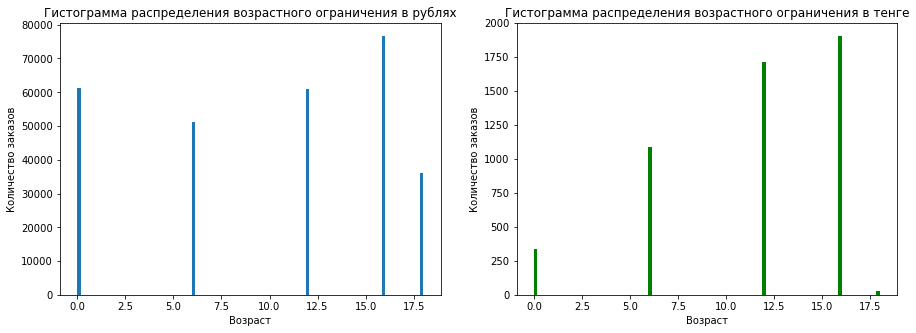

In [18]:
# Выводим статистику по необходимым количественным столбцам датафреймов
display(rub[['age_limit', 'revenue', 'tickets_count', 'total', 'days_since_prev']].describe(),
        kzt[['age_limit', 'revenue', 'tickets_count', 'total', 'days_since_prev']].describe())

display(sorted(rub['age_limit'].unique()),
        sorted(kzt['age_limit'].unique()))

# Визуализируем распределение возрастов
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(rub['age_limit'], bins = 100)
plt.title('Гистограмма распределения возрастного ограничения в рублях')
plt.xlabel('Возраст')
plt.ylabel('Количество заказов')

plt.subplot(1, 2, 2)
plt.hist(kzt['age_limit'], bins = 100, color = 'green')
plt.title('Гистограмма распределения возрастного ограничения в тенге')
plt.xlabel('Возраст')
plt.ylabel('Количество заказов')

plt.show()


Статистика выручки по рублям:
count    285780.000000
mean        547.568333
std         871.524559
min         -90.760000
25%         113.827500
50%         346.100000
75%         791.700000
max       81174.540000
Name: revenue, dtype: float64

Статистика выручки по тенге:
count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64


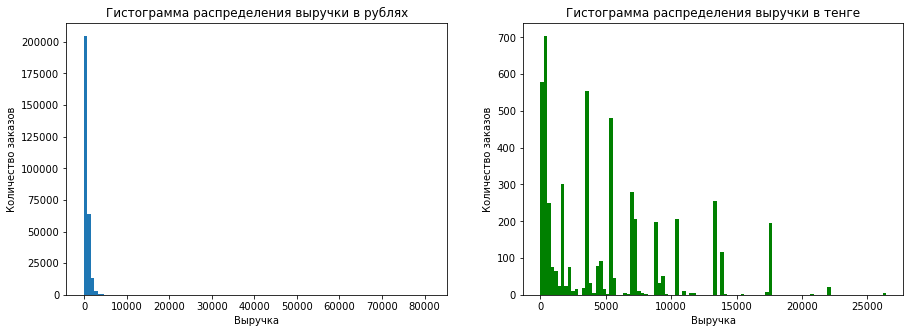

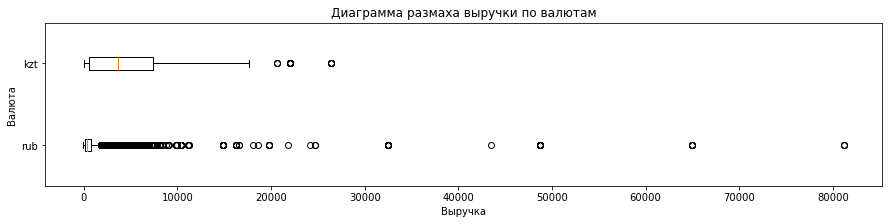

In [19]:
# Анализируем данные по выручке
print(f"\nСтатистика выручки по рублям:\n{rub['revenue'].describe()}")
print(f"\nСтатистика выручки по тенге:\n{kzt['revenue'].describe()}")

# Визуализируем распределение выручки
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)                                 # левое место для двух графиков в ряд
plt.hist(rub['revenue'], bins=100)
plt.title('Гистограмма распределения выручки в рублях')
plt.xlabel('Выручка')
plt.ylabel('Количество заказов')

plt.subplot(1, 2, 2)                                 # правое место для двух графиков в ряд
plt.hist(kzt['revenue'], bins=100, color='green')
plt.title('Гистограмма распределения выручки в тенге')
plt.xlabel('Выручка')
plt.ylabel('Количество заказов')

plt.figure(figsize=(15, 3))
plt.boxplot([rub['revenue'], kzt['revenue']], labels=['rub', 'kzt'], vert=False)
plt.title('Диаграмма размаха выручки по валютам')
plt.xlabel('Выручка')
plt.ylabel('Валюта')

plt.show()


Статистика количества билетов по рублям:
count    285780.000000
mean          2.754077
std           1.171419
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

Статистика количества билетов по тенге:
count    5069.000000
mean        2.762872
std         1.115558
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: tickets_count, dtype: float64


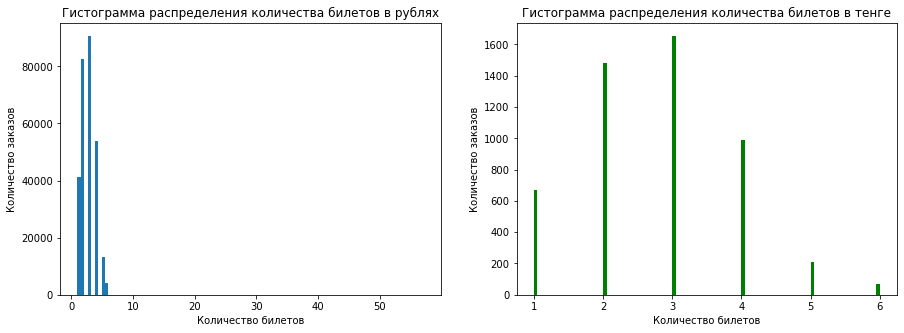

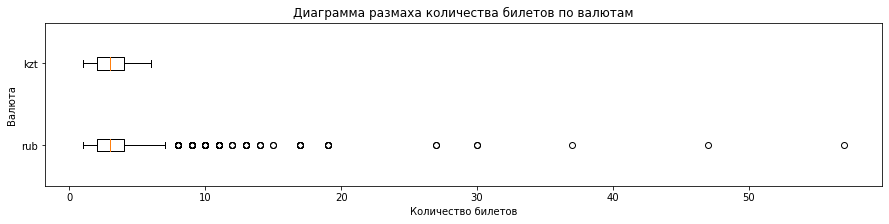

In [20]:
# Анализируем данные по количеству билетов в заказе
print(f"\nСтатистика количества билетов по рублям:\n{rub['tickets_count'].describe()}")
print(f"\nСтатистика количества билетов по тенге:\n{kzt['tickets_count'].describe()}")

# Визуализируем распределение выручки
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)                                 # левое место для двух графиков в ряд
plt.hist(rub['tickets_count'], bins=100)
plt.title('Гистограмма распределения количества билетов в рублях')
plt.xlabel('Количество билетов')
plt.ylabel('Количество заказов')

plt.subplot(1, 2, 2)                                 # правое место для двух графиков в ряд
plt.hist(kzt['tickets_count'], bins=100, color='green')
plt.title('Гистограмма распределения количества билетов в тенге')
plt.xlabel('Количество билетов')
plt.ylabel('Количество заказов')

plt.figure(figsize=(15, 3))
plt.boxplot([rub['tickets_count'], kzt['tickets_count']], labels=['rub', 'kzt'], vert=False)
plt.title('Диаграмма размаха количества билетов по валютам')
plt.xlabel('Количество билетов')
plt.ylabel('Валюта')

plt.show()

In [21]:
# Фильтруем по 99-му процентилю выручку по обеим валютам
rub_rev = rub[rub['revenue'] <= rub['revenue'].quantile(0.99)]
kzt_new = kzt[kzt['revenue'] <= kzt['revenue'].quantile(0.99)]

print(f"Потеряно записей (rub): {len(rub) - len(rub_rev)}")
print(f"Потеряно записей (kzt): {len(kzt) - len(kzt_new)}")

Потеряно записей (rub): 2858
Потеряно записей (kzt): 29


In [22]:
# Фильтруем по 99-му процентилю количество билетов только в рублях
rub_new = rub_rev[rub_rev['tickets_count'] <= rub_rev['tickets_count'].quantile(0.99)]
print(f"Потеряно записей (rub): {len(rub_rev) - len(rub_new)}")

Потеряно записей (rub): 180


In [23]:
# Выводим результаты фильтрации
print(f"\nРезультаты фильтрации:")

# для рублей
print(f"\nБыло  строк (rub): {len(rub)}")
print(f"Стало строк (rub): {len(rub_new)}")
rub_abs = len(rub) - len(rub_new)
rub_otn = (rub_abs / len(rub)) * 100
print(f"   Потеряно строк: {rub_abs} ({rub_otn:.2f}%)")

# для тенге
print(f"\nБыло  строк (kzt): {len(kzt)}")
print(f"Стало строк (kzt): {len(kzt_new)}")
kzt_abs = len(kzt) - len(kzt_new)
kzt_otn = (kzt_abs / len(kzt)) * 100
print(f"   Потеряно строк: {kzt_abs} ({kzt_otn:.2f}%)")


Результаты фильтрации:

Было  строк (rub): 285780
Стало строк (rub): 282742
   Потеряно строк: 3038 (1.06%)

Было  строк (kzt): 5069
Стало строк (kzt): 5040
   Потеряно строк: 29 (0.57%)


Поскольку данные представлены в разных валютах, датафрейм был сначала разделен по ним. Далее были проанализированы основные столбцы для каждой валюты.
- По `age_limit` определено, что возрастные ограничения имеют фиксированные стандартные значения без невалидных величин. У обеих валют распределение не является равномерным. Среднее значение показывает, что в целом пользователи тяготеют к младшим и средним возрастным группам, хотя у Казахстана (в отличие от России) категория 0+ незначительна.
- Частота покупок `days_since_prev` чуть ниже в Казахстане (4 дня), чем в России (3 дня). Но "однодневные" покупки и длинные паузы преобладают у обеих валют.
- По `revenue` определено, что данные требуют фильтрации выбросов, потому что max выручки в обоих случаях сильно превышают 75-й процентиль из-за чего среднее значение ненадежно и лучше опираться на медиану. Было принято решение отсеять аномалии, ограничив выборку 99-м процентилем. Это позволило убрать экстремально дорогие заказы, искажающие анализ. Кроме того, в выборке `rub` имеются отрицательные значения, как по `revenue`, так и по `total`, возможно это возвраты.
- По `tickets_count` данные в рублях имеют экстремально высокий max (57), который является выбросом, что сильно искажает среднее значение, ведь по данным 75% всех заказов содержат не более 4 билетов. Было принято решение отсеять аномалии в рублях, ограничив выборку 99-м процентилем. Выбросов в данных с количеством билетов в тенге не обнаружено, данные корректны и фильтрация не потребовалась.

В результате фильтрации было отсечено чуть больше 1% данных с российской валютой и менее 1% данных с казахстанским тенге.

<a id='metka_2_3'></a>
### Проверка дубликатов

<a id='metka_2_3_1'></a>
#### Явные дубликаты

In [24]:
# Проверяем наличие явных дубликатов
print(f"Количество явных дубликатов (rub): {rub_new.duplicated().sum()}")
print(f"Количество явных дубликатов (kzt): {kzt_new.duplicated().sum()}")

Количество явных дубликатов (rub): 0
Количество явных дубликатов (kzt): 0


<a id='metka_2_3_2'></a>
#### Неявные дубликаты

In [25]:
# Проверяем наличие неявных дубликатов (одинаковый идентификатор, разное содержание)
print("Найдено неявных дубликатов по order_id (rub):", rub_new.duplicated(subset = ['order_id']).sum())
print("Найдено неявных дубликатов по order_id (kzt):", kzt_new.duplicated(subset = ['order_id']).sum())

# Проверяем наличие неявных дубликатов (разный идентификатор, одинаковое содержание)
# и исключаем из наших датафреймов уникальные идентификаторы заказа
rub_no_id = rub_new.columns.difference(['order_id', 'days_since_prev'])
kzt_no_id = kzt_new.columns.difference(['order_id', 'days_since_prev'])
print(f"Найдено неявных дубликатов по содержанию (rub): {rub_new.duplicated(subset = rub_no_id).sum()}")
print(f"Найдено неявных дубликатов по содержанию (kzt): {kzt_new.duplicated(subset = kzt_no_id).sum()}")

Найдено неявных дубликатов по order_id (rub): 0
Найдено неявных дубликатов по order_id (kzt): 0
Найдено неявных дубликатов по содержанию (rub): 38
Найдено неявных дубликатов по содержанию (kzt): 1


In [26]:
# Выводим первые найденные дубли для анализа (если они есть)
display(rub_new[rub_new.duplicated(subset = rub_no_id, keep = False)].head(2),
        kzt_new[kzt_new.duplicated(subset = kzt_no_id, keep = False)].head(2))

# Удаляем неявные дубликаты, оставляя их первое вхождение (если они есть)
rub_clean = rub_new.drop_duplicates(subset = rub_no_id, keep = 'first')
kzt_clean = kzt_new.drop_duplicates(subset = kzt_no_id, keep = 'first')

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
209252,3320153,ae8e3d5af3036a6,2024-07-30,2024-07-30 11:20:46,533803,нет,16,kzt,mobile,1849.41,...,0686ac7b-6f3e-4177-bb73-16b54acd1223,фестиваль,концерты,№4950,Шанырский регион,Широковка,162.0,3407.0,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7"
209254,3320211,ae8e3d5af3036a6,2024-07-30,2024-07-30 11:20:46,533803,нет,16,kzt,mobile,1849.41,...,0686ac7b-6f3e-4177-bb73-16b54acd1223,фестиваль,концерты,№4950,Шанырский регион,Широковка,162.0,3407.0,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7"


In [27]:
# Пересчитываем столбец с количеством дней с предыдущей покупки
df_rub = recalculate(rub_clean)
df_kzt = recalculate(kzt_clean)

In [28]:
# Выводим результаты обработки дубликатов
print(f"\nРезультаты обработки дубликатов:")

# для рублей
print(f"\nБыло  строк (rub): {len(rub_new)}")
print(f"Стало строк (rub): {len(df_rub)}")
rub_abs = len(rub_new) - len(df_rub)
rub_otn = (rub_abs / len(rub_new)) * 100
print(f"   Потеряно строк: {rub_abs} ({rub_otn:.2f}%)")

# для тенге
print(f"\nБыло  строк (kzt): {len(kzt_new)}")
print(f"Стало строк (kzt): {len(df_kzt)}")
kzt_abs = len(kzt_new) - len(df_kzt)
kzt_otn = (kzt_abs / len(kzt)) * 100
print(f"   Потеряно строк: {kzt_abs} ({kzt_otn:.2f}%)")


Результаты обработки дубликатов:

Было  строк (rub): 282742
Стало строк (rub): 282704
   Потеряно строк: 38 (0.01%)

Было  строк (kzt): 5040
Стало строк (kzt): 5039
   Потеряно строк: 1 (0.02%)


Итоги проверки наличия дубликатов:
- Явных дублей не обнаружено ни в одном из датафреймов.
- Неявных дублей по order_id не обнаружено ни в одном из датафреймов.
- Обнаружено 38 (rub) и 1 (kzt) неявных дублей по содержимому путём исключения из рассмотрения уникального идентификатора заказа билетов и связанного с ним количества дней между заказами. Визуальный анализ показал, что, видимо, одни и те же билеты были проданы дважды из-за сбоя в системе, т.к. все поля датафрейма совпадают. Было принято решение очистить датафреймы от неявных дублей, т.к. их ничтожно мало и основная масса данных была сохранена.
- Датасеты готовы к дальнейшим этапам анализа.

<a id='metka_2_4'></a>
### Проверка типов данных

In [29]:
# Определяем формат даты и времени датафреймов
display(df_rub['created_dt_msk'].head(), df_rub['created_ts_msk'].head(), df_tenge['data'].head())

0    2024-08-20
1    2024-07-23
2    2024-10-06
3    2024-07-13
4    2024-10-04
Name: created_dt_msk, dtype: object

0   2024-08-20 16:08:03
1   2024-07-23 18:36:24
2   2024-10-06 13:56:02
3   2024-07-13 19:40:48
4   2024-10-04 22:33:15
Name: created_ts_msk, dtype: datetime64[ns]

0    2024-01-10
1    2024-01-11
2    2024-01-12
3    2024-01-13
4    2024-01-14
Name: data, dtype: object

In [30]:
# Преобразовываем столбцы с датами из строкового типа (object) к типу datetime, задавая первоначальный формат

df_rub['created_dt_msk'] = pd.to_datetime(df_rub['created_dt_msk'], format = '%Y-%m-%d')
df_rub['created_ts_msk'] = pd.to_datetime(df_rub['created_ts_msk'], format = '%Y-%m-%d %H:%M:%S')

df_kzt['created_dt_msk'] = pd.to_datetime(df_kzt['created_dt_msk'], format = '%Y-%m-%d')
df_kzt['created_ts_msk'] = pd.to_datetime(df_kzt['created_ts_msk'], format = '%Y-%m-%d %H:%M:%S')

df_tenge['data'] = pd.to_datetime(df_tenge['data'], format = '%Y-%m-%d')

In [31]:
# Преобразовываем столбцы с повторяющимися значениями из строкового типа (object) к типу category
total_df = df_rub.append(df_kzt, ignore_index=True)
spisok = ['currency_code', 'device_type_canonical', 'event_type_description', 'event_type_main']
total_df[spisok] = total_df[spisok].astype('category')
df_tenge['cdx'] = df_tenge['cdx'].astype('category')

In [32]:
# Проверка преобразования типов
display(total_df.dtypes, df_tenge.dtypes)

order_id                           int64
user_id                           object
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
event_id                           int64
cinema_circuit                    object
age_limit                          int64
currency_code                   category
device_type_canonical           category
revenue                          float64
service_name                      object
tickets_count                      int64
total                            float64
days_since_prev                  float64
event_name                        object
event_type_description          category
event_type_main                 category
organizers                        object
region_name                       object
city_name                         object
city_id                          float64
venue_id                         float64
venue_name                        object
venue_address                     object
dtype: object

data       datetime64[ns]
nominal             int64
curs              float64
cdx              category
dtype: object

На этапе знакомства с данными (см. п.1.1) было определено, что не все столбцы датафреймов имеют типы данных, соответствующие содержимому:
- `created_dt_msk` и `created_ts_msk` были приведены к типу дата.
- `data` датафрейма с информацией о курсе тенге тоже приведен к типу дата.
- Преобразованы столбцы с повторяющимися значениями (`currency_code`, `device_type_canonical`, `event_type_description`, `event_type_main` и `cdx`) из строкового типа (object) к типу category.
- Позже, уже после рассчета всех необходимых дополнительных признаков, путем понижения размерности будут оптимизированы типы int64 у `age_limit` (данные представлены диапазоном чисел от 0 до 18) и у `nominal` (данные не превосходят значения 100).

<a id='metka_2_5'></a>
### Создание дополнительных столбцов

In [33]:
# Объединяем по дате датафрейм с тенге и датафрейм с его курсом в рублях
df_kzt_new = df_kzt.merge(
    df_tenge[['data', 'curs']], # присоединяем значения курса по дате
    left_on='created_dt_msk',
    right_on='data',
    how='left'
)

df_kzt_new = df_kzt_new.drop('data', axis=1) # удаляем ненужный столбец

# Создаем новый столбец выручки в рублях
df_kzt_new['revenue_rub'] = df_kzt_new['revenue'] * df_kzt_new['curs'] / 100 # выручку в тенге умножаем на курс деленный на 100
df_rub['revenue_rub'] = df_rub['revenue']                       # перезаписываем выручку в рублях в новый столбец без изменений

# Создаем новый столбец стоимости заказа в рублях
df_kzt_new['total_rub'] = df_kzt_new['total'] * df_kzt_new['curs'] / 100
df_rub['total_rub'] = df_rub['total']

# После всех преобразований и появления столбцов с единой валютой можно объединить датафреймы с разными валютами в один
total_df = df_rub.append(df_kzt_new, ignore_index=True) # "один под другим"
display(total_df.sample(n=3), total_df.shape) # выводим произвольные 3 строки объединенного датафрейма и его размерность

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,total_rub,curs
250060,1588998,e1b642f01ba7671,2024-09-12,2024-09-12 22:33:05,546149,нет,16,rub,mobile,986.09,...,№1399,Североярская область,Озёрск,2.0,1416.0,"Музей науки ""Спелка"" Инкорпорэйтед","наб. Карбышева, д. 9/7 стр. 3/1",986.09,8217.44,NaN
165074,8574141,8c667220caac082,2024-09-19,2024-09-19 21:58:03,448257,нет,16,rub,mobile,431.21,...,№894,Малиновоярский округ,Верховино,197.0,4222.0,"Искусствоведческая лекция ""Вектор"" Лтд","пер. Сельский, д. 4 к. 7",431.21,5390.13,NaN
130079,5304420,6a71629032a8560,2024-08-30,2024-08-30 19:22:01,44100,нет,16,rub,mobile,2439.97,...,№858,Озернинский край,Лесоярич,51.0,4023.0,"Училище искусств ""Трапеция"" Лимитед","алл. Революции, д. 53",2439.97,24399.67,NaN


(287743, 27)

In [34]:
# Создаем новый столбец выручки с продажи одного билета на мероприятие
total_df['one_ticket_revenue_rub'] = total_df['revenue_rub'] / total_df['tickets_count']
display(total_df.sample(n=3), total_df.shape) # выводим произвольные 3 строки объединенного датафрейма и его размерность

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,total_rub,curs,one_ticket_revenue_rub
182040,5468937,99c57bb78872125,2024-10-20,2024-10-20 17:30:23,416811,нет,18,rub,mobile,263.82,...,Серебринская область,Озёрчане,62.0,1398.0,"Народный театр ""Квалификация"" Инк","пр. Шишкина, д. 3/7 к. 868",263.82,3297.76,NaN,52.764
77687,2505108,3a27ec50fda9e42,2024-08-24,2024-08-24 11:53:54,531017,нет,0,rub,mobile,57.15,...,Каменевский регион,Глиногорск,213.0,3556.0,"Мастерская живого действия ""Ритм"" Инкорпорэйтед","пер. Запрудный, д. 4/4 стр. 4",57.15,1905.00,NaN,19.050
39845,7158129,18e9aead0a393e7,2024-10-10,2024-10-10 14:28:54,558630,нет,18,rub,mobile,406.52,...,Серебринская область,Озёрчане,62.0,1824.0,"Спектакль ""Мозаика"" Групп","наб. Коммунистическая, д. 528",406.52,4065.23,NaN,406.520


(287743, 28)

In [35]:
# Создаем новый столбец с номером месяца оформления заказа
total_df['month'] = total_df['created_dt_msk'].dt.month
display(total_df.sample(n=3), total_df.shape) # выводим произвольные 3 строки объединенного датафрейма и его размерность

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,total_rub,curs,one_ticket_revenue_rub,month
27301,6055926,0e6fa925c5f346f,2024-09-08,2024-09-08 13:55:02,546040,нет,16,rub,desktop,415.16,...,Теплоозёрск,15.0,1141.0,"Творческая лаборатория ""Лагуна"" Лтд","наб. Пирогова, д. 9",415.16,4151.61,NaN,207.58,9
238052,4204711,d048d0c124319e0,2024-07-09,2024-07-09 20:38:02,540436,нет,16,rub,mobile,0.00,...,Глиногорск,213.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1",0.00,0.00,NaN,0.00,7
196309,847410,a8bfe2d7ec940da,2024-06-19,2024-06-19 13:43:32,480585,нет,6,rub,mobile,6.86,...,Радужнояр,49.0,3440.0,"Киновидеостудия ""Angle"" Лтд","пер. Деповский, д. 120",6.86,228.60,NaN,6.86,6


(287743, 29)

In [36]:
# Создаём словарь: ключ — номер месяца, значение — сезон
seasons = {
    1: 'зима',
    2: 'зима',
    3: 'весна',
    4: 'весна',
    5: 'весна',
    6: 'лето',
    7: 'лето',
    8: 'лето',
    9: 'осень',
    10: 'осень',
    11: 'осень',
    12: 'зима'}

# Создаем новый столбец с информацией о сезонности
total_df['season'] = total_df['month'].map(seasons) # с помощью встроенного метода для замены значений по словарю
display(total_df.sample(n=3), total_df.shape)       # выводим произвольные 3 строки объединенного датафрейма и его размерность

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_id,venue_id,venue_name,venue_address,revenue_rub,total_rub,curs,one_ticket_revenue_rub,month,season
287111,3792708,d97ae11496e1f03,2024-09-26,2024-09-26 11:02:48,559937,нет,6,kzt,mobile,414.43,...,163.0,1533.0,"Клуб настольного тенниса ""Фазенда"" Инк","пер. Семашко, д. 8/7 стр. 7",79.815488,1596.313614,19.2591,26.605163,9,осень
252639,6381625,e3233f8c7eadd95,2024-09-16,2024-09-16 18:44:23,533756,нет,0,rub,mobile,53.47,...,10959.0,1894.0,"Лаборатория новых медиа ""Компас"" Лимитед","пр. Свободы, д. 312 стр. 60",53.470000,1069.320000,NaN,17.823333,9,осень
48067,3037954,1dda0ef3bf41b0e,2024-10-15,2024-10-15 08:12:41,583620,нет,0,rub,desktop,108.40,...,56.0,2803.0,"Центр искусства и культуры ""Попугай"" и партнеры","бул. Воровского, д. 917 к. 2",108.400000,3613.320000,NaN,27.100000,10,осень


(287743, 30)

In [37]:
# Оптимизируем тип путем понижения размерности
df_rub['age_limit'] = pd.to_numeric(df_rub['age_limit'], downcast='integer')
df_kzt['age_limit'] = pd.to_numeric(df_kzt['age_limit'], downcast='integer')
df_tenge['nominal'] = pd.to_numeric(df_tenge['nominal'], downcast='integer')

In [38]:
total_df.info()
total_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287743 entries, 0 to 287742
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287743 non-null  int64         
 1   user_id                 287743 non-null  object        
 2   created_dt_msk          287743 non-null  datetime64[ns]
 3   created_ts_msk          287743 non-null  datetime64[ns]
 4   event_id                287743 non-null  int64         
 5   cinema_circuit          287743 non-null  object        
 6   age_limit               287743 non-null  int64         
 7   currency_code           287743 non-null  object        
 8   device_type_canonical   287743 non-null  object        
 9   revenue                 287743 non-null  float64       
 10  service_name            287743 non-null  object        
 11  tickets_count           287743 non-null  int64         
 12  total                   287743

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_id,venue_id,venue_name,venue_address,revenue_rub,total_rub,curs,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",1521.94,10870.99,NaN,380.4850,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",289.45,2067.51,NaN,144.7250,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",1258.57,13984.16,NaN,314.6425,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",8.49,212.28,NaN,4.2450,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",1390.41,10695.43,NaN,463.4700,10,осень


<a id='metka_2_6'></a>
### Промежуточный вывод

In [39]:
# Выводим итоговые результаты предобработки данных (фильтрации по 99 процентилю и удаления дубликатов)
print(f"\nИтоговые результаты:")
print(f"\nБыло  строк: {len(rub) + len(kzt)}")
print(f"Стало строк: {len(total_df)}")
abs = len(rub) + len(kzt) - len(total_df)
otn = abs / (len(rub) + len(kzt)) * 100
print(f"   Потеряно: {abs} ({otn:.2f}%)")


Итоговые результаты:

Было  строк: 290849
Стало строк: 287743
   Потеряно: 3106 (1.07%)


In [40]:
# Выводим информацию только о столбцах с пропусками
total_df.isna().sum()[total_df.isna().sum() > 0]

days_since_prev     22617
city_id               238
venue_id              238
curs               282704
dtype: int64

- Было заменено 238 пропусков в категориальных столбцах на значение unknown, которые образовались после слияния двух датафреймов, пропуски в количественных столбцах не должны повлиять на дальнейший анализ и были оставлены без изменений.
- Предобработка проводилась в разных валютах.
- В результате фильтрации по 99 процентилю по выручке и количеству билетов было отсечено чуть больше 1% данных с российской валютой и менее 1% данных с казахстанским тенге.
- Удалено 39 строк неявных дублей (0,01%).
- В общей сложности было потеряно 1,07% исходных данных, что незначительно для дальнейшего анализа.
- Были преобразованы 3 столбца с датами из строкового типа (object) к типу datetime, 6 столбцов из строкового типа (object) к типу category и оптимизирован тип 2 столбцов путем понижения размерности.
- В итоге получен общий датафрейм, где к имеющимся 24 столбцам был присоединен столбец с курсом тенге и позже добавлено еще 5 (в т.ч. конвертируемые выручка и стоимость заказа) новых столбцов, которые предположительно будут использоваться в дальнейшем анализе. Пропуски в новых столбцах отсутствуют.

<a id='metka_3'></a>
## Исследовательский анализ данных

<a id='metka_3_1'></a>
### Анализ распределения заказов по сегментам и их сезонные изменения

 Далее изучим и выявим закономерности в активности пользователей, привязанные к времени года, и разберем структуру спроса по трем ключевым разрезам:
- `event_type_main` - тип мероприятия,
- `device_type_canonical`- тип устройства,
- `age_limit` - категория мероприятий по возрастному рейтингу.

В результате анализа сводных таблиц (их визуализаций) мы должны будем получить список сезонных инсайтов, которые, возможно, использовать для планирования следующего года.

<a id='metka_3_1_1'></a>
#### Количество заказов для каждого месяца

,Абсолютн.,Доля,Процентн.
month,,,
6,34326,0.119294,11.929395
7,40379,0.140330,14.033009
8,44536,0.154777,15.477701
9,69291,0.240809,24.080864
10,99211,0.344790,34.479032


device_type_canonical,desktop,mobile
month,,
6,6898,27428
7,7883,32496
8,8291,36245
9,13371,55920
10,20885,78326


age_limit,0,6,12,16,18
month,,,,,
6,5633,5990,8111,9881,4711
7,6556,7833,7645,11770,6575
8,9194,7856,8763,12117,6606
9,15918,12772,15812,17659,7130
10,23888,16930,21409,26556,10428


event_type_main,unknown,выставки,другое,концерты,спорт,стендап,театр,ёлки
month,,,,,,,,
6,179,614,8848,15489,260,1516,7354,66
7,6,1017,11449,16753,714,2144,8229,67
8,31,785,12003,18509,2030,2686,8352,140
9,11,847,14522,24916,7971,3047,17635,342
10,11,1589,18633,37765,10899,3876,25091,1347


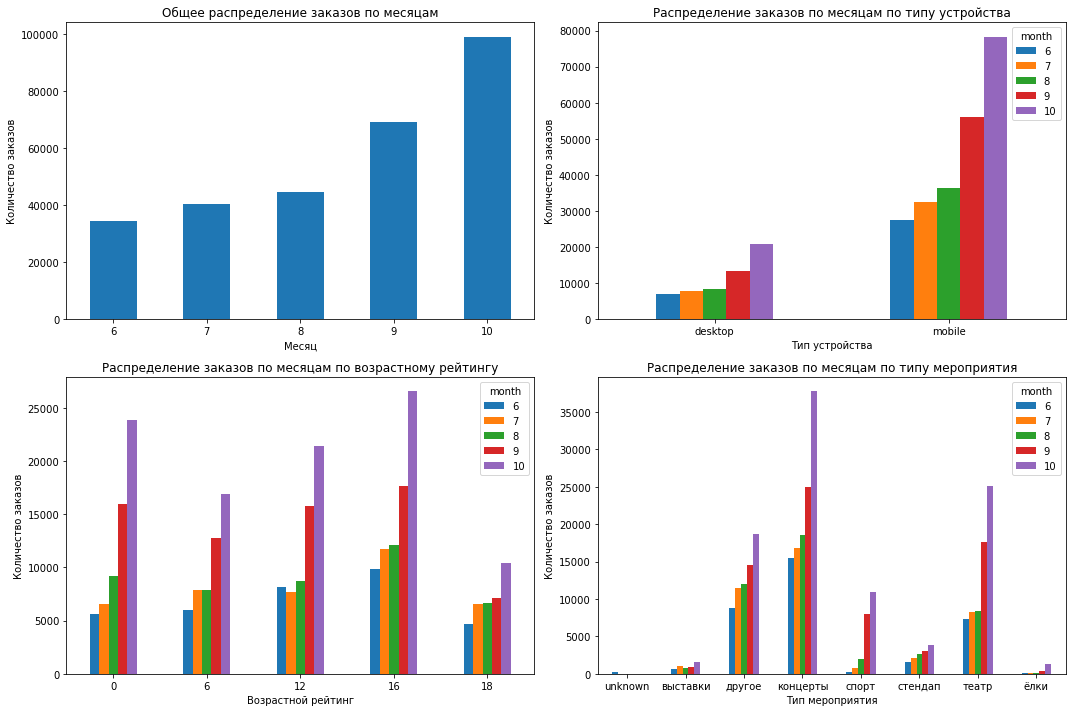

In [41]:
# Рассчитываем ежемесячное распределение заказов по сегментам
month_distribution = total_df.groupby('month')['order_id'].count() # в общем
month_device_distribution = total_df.groupby(['month', 'device_type_canonical'])['order_id'].count().unstack()   # по устройству
month_age_distribution = total_df.groupby(['month', 'age_limit'])['order_id'].count().unstack()        # по возрастному рейтингу
month_event_distribution = total_df.groupby(['month', 'event_type_main'])['order_id'].count().unstack()    # по типу мероприятия

# Создаем итоговую таблицу для общего случая
month_table = pd.concat([
    month_distribution.rename('Абсолютн.'),
    (month_distribution / month_distribution.sum()).rename('Доля'),
    ((month_distribution / month_distribution.sum()) * 100).rename('Процентн.')
], axis=1)

# Выводим рассчеты
display(
    month_table,
    month_device_distribution,
    month_age_distribution,
    month_event_distribution)

# Визуализируем все 4 распределения
plt.figure(figsize = (15, 10))

plt.subplot(2, 2, 1)
month_distribution.plot(kind = 'bar', ax = plt.gca())
plt.title('Общее распределение заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.xticks(rotation = 0)

plt.subplot(2, 2, 2)
month_device_distribution.T.plot(kind = 'bar', ax = plt.gca(), legend = True)
plt.title('Распределение заказов по месяцам по типу устройства')
plt.xlabel('Тип устройства')
plt.ylabel('Количество заказов')
plt.xticks(rotation = 0)

plt.subplot(2, 2, 3)
month_age_distribution.T.plot(kind = 'bar', ax = plt.gca(), legend = True)
plt.title('Распределение заказов по месяцам по возрастному рейтингу')
plt.xlabel('Возрастной рейтинг')
plt.ylabel('Количество заказов')
plt.xticks(rotation = 0)

plt.subplot(2, 2, 4)
month_event_distribution.T.plot(kind = 'bar', ax = plt.gca(), legend = True)
plt.title('Распределение заказов по месяцам по типу мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Количество заказов')
plt.xticks(rotation = 0)

plt.tight_layout()
plt.show()

<a id='metka_3_1_2'></a>
#### Распределение заказов осеннего и летнего периодов

,Абсолютн.,Доля,Процентн.
season,,,
лето,119241,0.414401,41.440105
осень,168502,0.585599,58.559895


device_type_canonical,desktop,mobile
season,,
лето,0.193490,0.806510
осень,0.203297,0.796703


age_limit,0,6,12,16,18
season,,,,,
лето,0.179326,0.181808,0.205626,0.283191,0.150049
осень,0.236235,0.176271,0.220894,0.262400,0.104201


event_type_main,unknown,выставки,другое,концерты,спорт,стендап,театр,ёлки
season,,,,,,,,
лето,0.001811,0.020261,0.270880,0.425617,0.025193,0.053220,0.200728,0.002289
осень,0.000131,0.014457,0.196763,0.371990,0.111987,0.041086,0.253564,0.010024


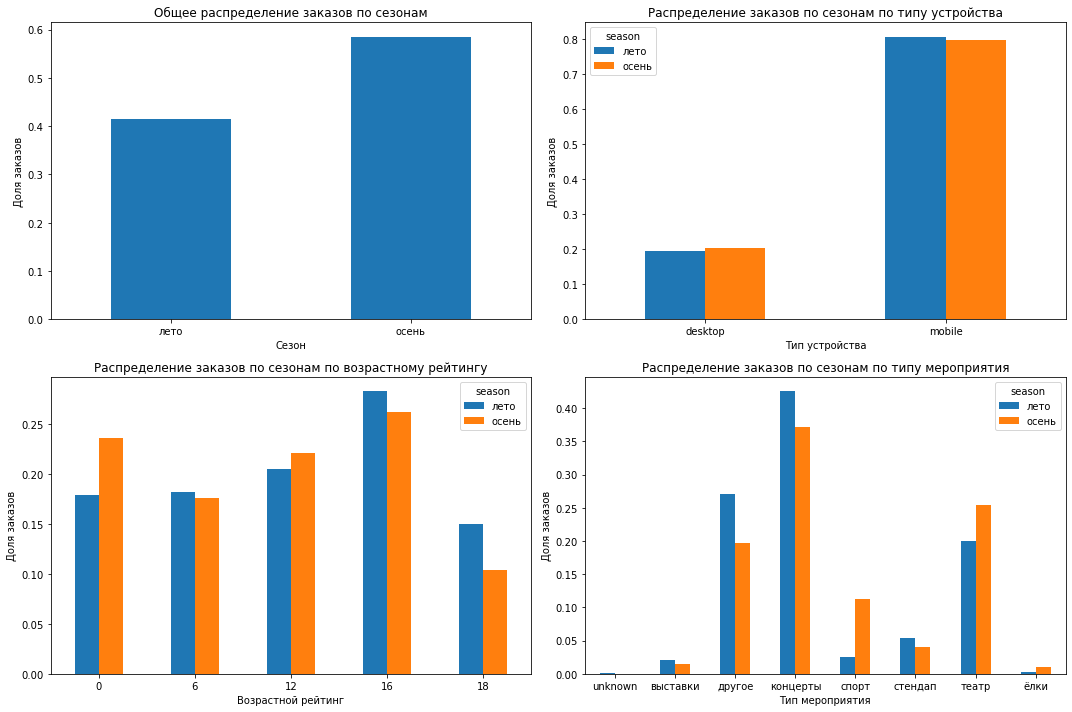

In [42]:
# Рассчитываем сезонное распределение заказов по сегментам в долях
season_distribution = total_df.groupby('season')['order_id'].count() # в общем
season_device_distribution = total_df.groupby(['season', 'device_type_canonical']) \
                             ['order_id'].count().unstack().div(season_distribution, axis=0) # по устройству
season_age_distribution = total_df.groupby(['season', 'age_limit']) \
                             ['order_id'].count().unstack().div(season_distribution, axis=0) # по возрастному рейтингу
season_event_distribution = total_df.groupby(['season', 'event_type_main']) \
                             ['order_id'].count().unstack().div(season_distribution, axis=0) # по типу мероприятия

# Создаем итоговую таблицу для общего случая
season_table = pd.concat([
    season_distribution.rename('Абсолютн.'),
    (season_distribution / season_distribution.sum()).rename('Доля'),
    ((season_distribution / season_distribution.sum()) * 100).rename('Процентн.')
], axis=1)

# Выводим расчеты
display(
    season_table,
    season_device_distribution,
    season_age_distribution,
    season_event_distribution)

# Визуализируем все 4 распределения
plt.figure(figsize = (15, 10))

plt.subplot(2, 2, 1)
(season_distribution / season_distribution.sum()).plot(kind = 'bar', ax = plt.gca())
plt.title('Общее распределение заказов по сезонам')
plt.xlabel('Сезон')
plt.ylabel('Доля заказов')
plt.xticks(rotation = 0)

plt.subplot(2, 2, 2)
season_device_distribution.T.plot(kind = 'bar', ax = plt.gca(), legend = True)
plt.title('Распределение заказов по сезонам по типу устройства')
plt.xlabel('Тип устройства')
plt.ylabel('Доля заказов')
plt.xticks(rotation = 0)

plt.subplot(2, 2, 3)
season_age_distribution.T.plot(kind = 'bar', ax = plt.gca(), legend = True)
plt.title('Распределение заказов по сезонам по возрастному рейтингу')
plt.xlabel('Возрастной рейтинг')
plt.ylabel('Доля заказов')
plt.xticks(rotation = 0)

plt.subplot(2, 2, 4)
season_event_distribution.T.plot(kind = 'bar', ax = plt.gca(), legend = True)
plt.title('Распределение заказов по сезонам по типу мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля заказов')
plt.xticks(rotation = 0)

plt.tight_layout()
plt.show()

<a id='metka_3_1_3'></a>
#### Выручка с продажи одного билета

event_type_main,unknown,выставки,другое,концерты,спорт,стендап,театр,ёлки
season,,,,,,,,
лето,4.065883,89.398918,82.356077,302.699730,50.594603,215.220898,211.520387,263.499330
осень,14.579592,92.245467,82.089444,269.316983,49.911739,228.673568,176.408521,217.891186


event_type_main
unknown     258.583622
выставки      3.184098
другое       -0.323756
концерты    -11.028337
спорт        -1.349679
стендап       6.250634
театр       -16.599755
ёлки        -17.308638
dtype: float64

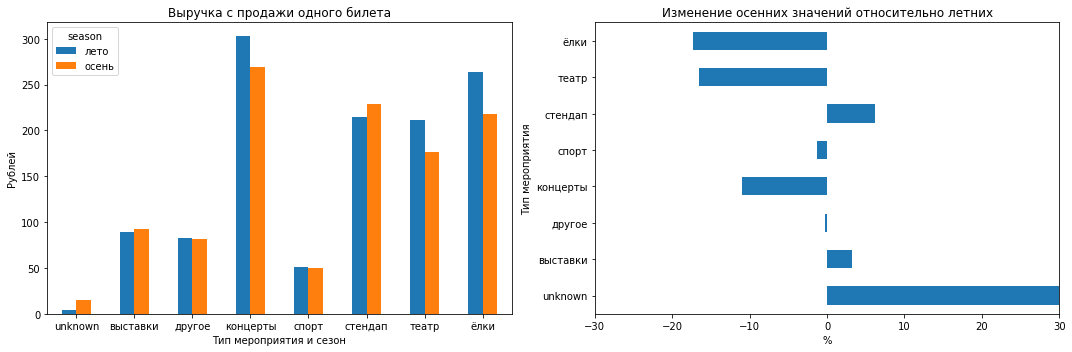

In [43]:
# Рассчитываем выручку с продажи одного билета в зависимости от типа мероприятия и сезона
avg_revenue = (total_df.groupby(['season', 'event_type_main'])['revenue_rub'].sum() / 
              total_df.groupby(['season', 'event_type_main'])['tickets_count'].sum())

# Рассчитываем относительное изменение осенних значений по сравнению с летними
relative_change = (avg_revenue['осень'] / avg_revenue['лето'] - 1) * 100

# Выводим полученные рассчеты
display(avg_revenue.unstack(), relative_change)

# Визуализируем
plt.figure(figsize = (15, 5))

plt.subplot(1, 2, 1)
avg_revenue.unstack().T.plot(kind = 'bar', ax = plt.gca(), legend = True)
plt.title ('Выручка с продажи одного билета')
plt.xlabel('Тип мероприятия и сезон')
plt.ylabel('Рублей')
plt.xticks(rotation = 0)

plt.subplot(1, 2, 2)
relative_change.plot(kind = 'barh', ax = plt.gca())
plt.title ('Изменение осенних значений относительно летних')
plt.ylabel('Тип мероприятия')
plt.xlabel('%')
plt.xlim(-30, 30)       # центрируем ось вокруг нуля
plt.xticks(rotation = 0)

plt.tight_layout()
plt.show()

<a id='metka_3_1_4'></a>
#### Промежуточный вывод

- Количество заказов стабильно растет с июня по октябрь и наблюдается резкий рост общей доли заказов в осеннем сезоне по сравнению с летним. Как летом, так и осенью пользователи предпочитают совершать покупки с мобильных устройств (удобство бронирования в дороге, мобильность важна в период подготовки к праздникам), а стационарные показывают более умеренный рост. Осенью аудитория становится более разнообразной, смещаясь в сторону и детского, и молодежного контента (начинается предновогодний период). Каникулы (время, когда родители могут побаловать себя пока дети у бабушки) закончились, впереди Новый год и наблюдается снижение доли самого строгого рейтинга 18+ в пользу молодой категории. Концерты являются безоговорочным лидером по доле заказов в любой сезон, но их относительное влияние ослабевает с приходом осени. В октябре наблюдается взрывной рост заказов именно на детские новогодние мероприятия в предновогодний период. Кроме того, осень — это классический сезон старта спортивных лиг и турниров. Поэтому спортивные мероприятия - драйвер продаж наряду с ёлками и театром (осень - начало театрального сезона).
- Средняя стоимость одного билета изменилась для большинства типов мероприятий при переходе от лета к осени. Наиболее заметное падение наблюдается у ёлок, театров и концертов. Исключением стал стендап, где стоимость, напротив, выросла. Общее осеннее удешевление билетов по основным массовым категориям возможно для периода роста спроса, ведь обычно ближе к дате мероприятия (Новогодние спектакли и постановки) часто запускают акции и снижают цены.
- Все изменения — рост заказов, смещение в сторону детского контента, удешевление билетов, лидерство мобильных устройств — связаны с сокращением времени перед праздниками. Даже если это разовый всплеск (ведь мы рассматриваем только небольшой временной промежуток одного года), а не устойчивая сезонность (можно проводить долгосрочную стратегию), то эти данные все равно позволяют оптимизировать ресурсы на следующий год и получить определенный опыт.

<a id='metka_3_2'></a>
### Осенняя активность пользователей

<a id='metka_3_2_1'></a>
#### Дневная динамика

Далее изучим активность пользователей осенью 2024 года. Рассмотрим ежедневную осеннюю активность и проследим динамику четырёх ключевых метрик:
- общего числа заказов,
- количества активных пользователей `DAU`,
- среднего числа заказов на одного пользователя,
- средней стоимости одного билета.

Мы отфильтруем и агрегируем на дневном уровне данные, изучим визуализацию их динамики и сопоставим метрики. Картина дневной активности с выделением закономерностей ляжет в основу решений по планированию рекламных активностей и управлению ассортиментом.

In [44]:
# Отфильтровываем только осень
autumn_df = total_df[total_df['season'] == 'осень'].copy()

# Создаем столбец "цена за 1 билет" в исходном осеннем датафрейме
autumn_df['price'] = autumn_df['total_rub'] / autumn_df['tickets_count']
autumn_df.head()

# Создаем сводную таблицу, сгруппированную по дате, с нужными метриками
pivot_df = autumn_df.groupby('created_dt_msk').agg(
    total_orders = ('order_id', 'count'),           # общее число заказов
    DAU = ('user_id', 'nunique'),                   # количество активных пользователей
    total_revenue = ('revenue_rub', 'sum'),         # общая выручка
    avg_price = ('price', 'mean'),                  # cреднее значение цены билета по дням
    total_tickets = ('tickets_count', 'sum')        # общее число билетов
).reset_index()

# Добавляем в сводную таблицу столбец со средним числом заказов на одного пользователя
pivot_df['orders_per_user'] = pivot_df['total_orders'] / pivot_df['DAU']

# Добавляем в сводную таблицу столбец со средней выручкой одного заказа
pivot_df['revenue_pur_order'] = pivot_df['total_revenue'] / pivot_df['total_orders']

# Добавляем в сводную таблицу столбец со средней стоимостью одного билета
pivot_df['revenue_pur_ticket'] = pivot_df['total_revenue'] / pivot_df['total_tickets']

pivot_df.head()

,created_dt_msk,total_orders,DAU,total_revenue,avg_price,total_tickets,orders_per_user,revenue_pur_order,revenue_pur_ticket
0,2024-09-01,1327,564,7.262059e+05,2290.044165,3718,2.352837,547.253889,195.321654
1,2024-09-02,1380,574,7.035384e+05,2192.251918,3704,2.404181,509.810408,189.940163
2,2024-09-03,5111,778,1.151204e+06,1293.704611,15290,6.569409,225.240536,75.291326
3,2024-09-04,1772,684,8.557010e+05,2153.421751,4791,2.590643,482.901237,178.605926
4,2024-09-05,1940,739,9.866274e+05,2193.372496,5177,2.625169,508.570843,190.578991


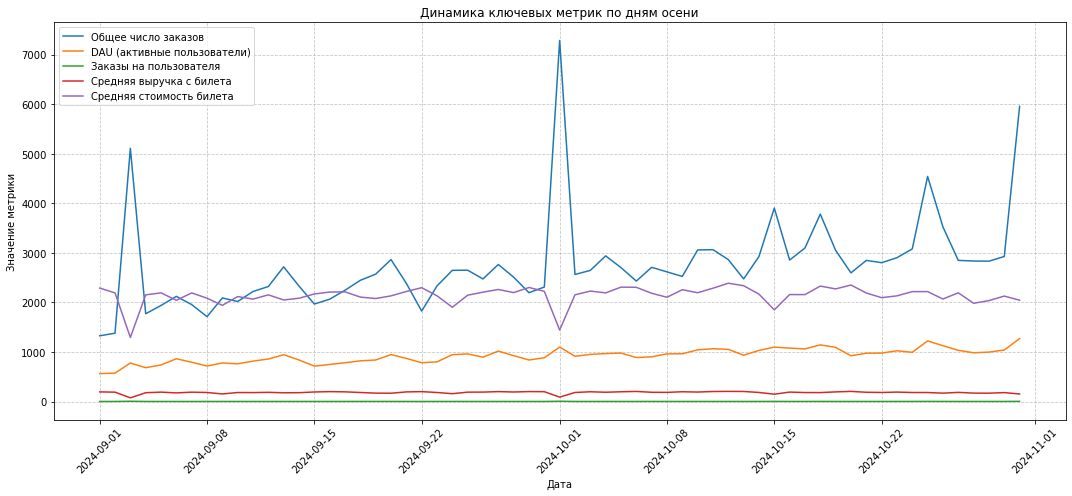

In [45]:
# Визуализируем метрики на одном графике
plt.figure(figsize=(15, 7))

plt.plot(pivot_df['created_dt_msk'], pivot_df['total_orders'], label = 'Общее число заказов')
plt.plot(pivot_df['created_dt_msk'], pivot_df['DAU'], label = 'DAU (активные пользователи)')
plt.plot(pivot_df['created_dt_msk'], pivot_df['orders_per_user'], label = 'Заказы на пользователя')
plt.plot(pivot_df['created_dt_msk'], pivot_df['revenue_pur_ticket'], label = 'Средняя выручка с билета')
plt.plot(pivot_df['created_dt_msk'], pivot_df['avg_price'], label = 'Средняя стоимость билета')

plt.title('Динамика ключевых метрик по дням осени')
plt.xlabel('Дата')
plt.ylabel('Значение метрики')
plt.legend(loc='upper left')              # легенда
plt.grid(True, linestyle='--', alpha=0.7) # cетка
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

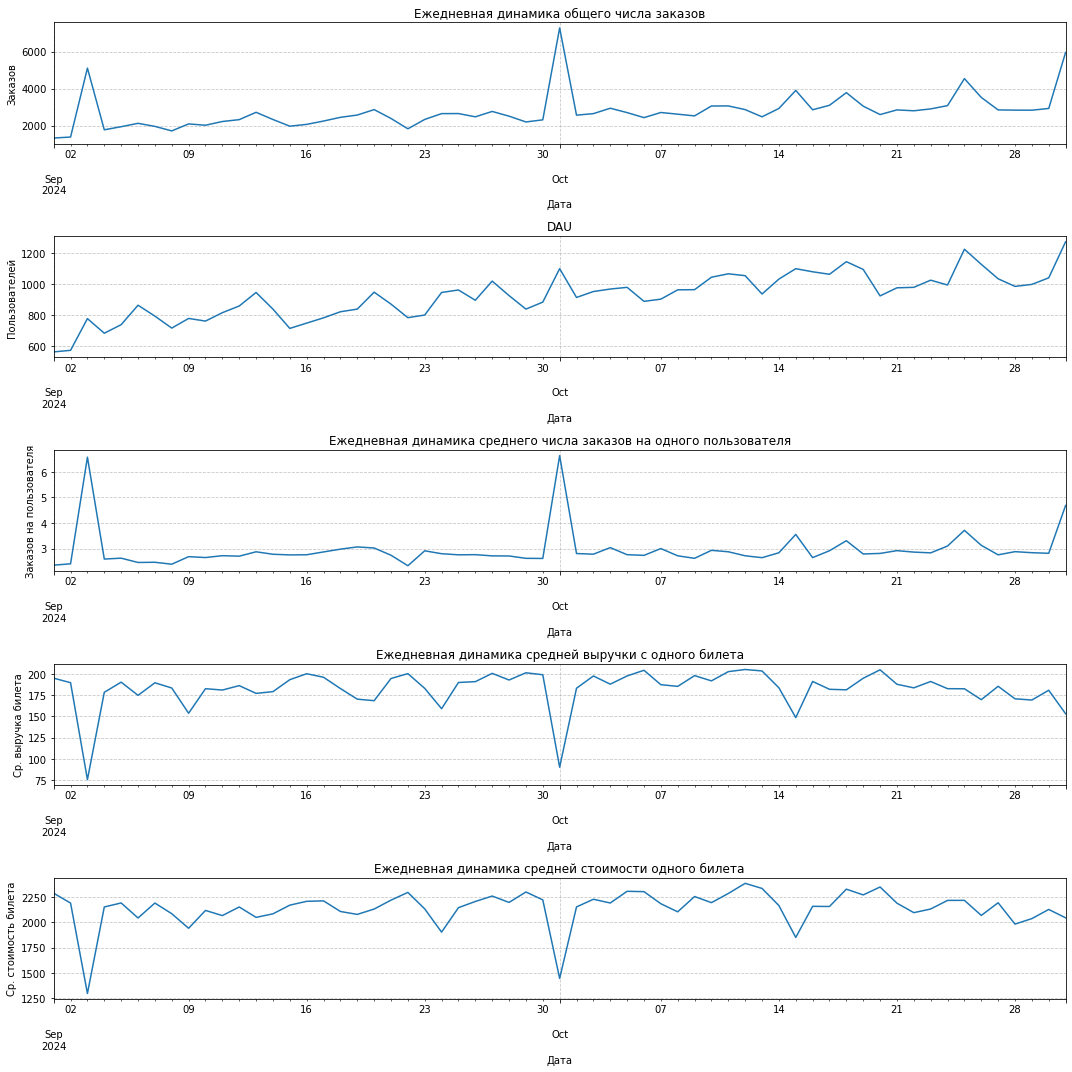

In [46]:
# Визуализируем все метрики отдельно
plt.figure(figsize = (15, 15))

plt.subplot(5, 1, 1)
pivot_df[['created_dt_msk', 'total_orders']].plot('created_dt_msk', ax = plt.gca(), legend = False)
plt.title('Ежедневная динамика общего числа заказов')
plt.xlabel('Дата')
plt.ylabel('Заказов')
plt.grid(True, linestyle = '--', alpha=0.7) # cетка

plt.subplot(5, 1, 2)
pivot_df[['created_dt_msk', 'DAU']].plot('created_dt_msk', ax = plt.gca(), legend = False)
plt.title('DAU')
plt.xlabel('Дата')
plt.ylabel('Пользователей')
plt.grid(True, linestyle = '--', alpha=0.7) # cетка

plt.subplot(5, 1, 3)
pivot_df[['created_dt_msk', 'orders_per_user']].plot('created_dt_msk', ax = plt.gca(), legend = False)
plt.title('Ежедневная динамика среднего числа заказов на одного пользователя')
plt.xlabel('Дата')
plt.ylabel('Заказов на пользователя')
plt.grid(True, linestyle = '--', alpha=0.7) # cетка

plt.subplot(5, 1, 4)
pivot_df[['created_dt_msk', 'revenue_pur_ticket']].plot('created_dt_msk', ax = plt.gca(), legend = False)
plt.title('Ежедневная динамика средней выручки c одного билета')
plt.xlabel('Дата')
plt.ylabel('Ср. выручка билета')
plt.grid(True, linestyle = '--', alpha=0.7) # cетка

plt.subplot(5, 1, 5)
pivot_df[['created_dt_msk', 'avg_price']].plot('created_dt_msk', ax = plt.gca(), legend = False)
plt.title('Ежедневная динамика средней стоимости одного билета')
plt.xlabel('Дата')
plt.ylabel('Ср. стоимость билета')
plt.grid(True, linestyle = '--', alpha=0.7) # cетка

plt.tight_layout()
plt.show()

<a id='metka_3_2_2'></a>
#### Недельная цикличность

Выделим дни недели и сравним пользовательскую активность в будни и выходные

In [47]:
# Добавляем столбец с днями недели в суточный датафрейм
pivot_df['day'] = pivot_df['created_dt_msk'].dt.day_name()

# Создаем сводную таблицу, сгруппированную по дням недели, с нужными метриками и берем среднее по суточным значениям
avg_pivot_df = pivot_df.groupby('day').agg(
    avg_total_orders = ('total_orders', 'mean'),            # среднее число заказов
    avg_DAU = ('DAU', 'mean'),                              # среднее число активных пользователей
    avg_orders_per_user = ('orders_per_user', 'mean'),      # среднее число заказов на одного пользователя
    avg_revenue_pur_order = ('revenue_pur_order', 'mean'),  # средняя стоимость одного заказа
    avg2_price = ('avg_price', 'mean'),                     # средняя стоимость одного билета
    avg_revenue_pur_ticket = ('revenue_pur_ticket', 'mean') # средняя выручка с одного билета
).reset_index()

avg_pivot_df = avg_pivot_df.sort_values('day', key=lambda x: x.map({'Monday': 0,
                                                                    'Tuesday': 1,
                                                                    'Wednesday': 2,
                                                                    'Thursday': 3,
                                                                    'Friday': 4,
                                                                    'Saturday': 5,
                                                                    'Sunday': 6}))
avg_pivot_df

,day,avg_total_orders,avg_DAU,avg_orders_per_user,avg_revenue_pur_order,avg2_price,avg_revenue_pur_ticket
1,Monday,2389.111111,853.666667,2.778676,499.097976,2136.591632,184.155745
5,Tuesday,3496.333333,934.111111,3.720872,426.882048,1895.994842,154.579088
6,Wednesday,2540.888889,922.888889,2.751686,500.775647,2145.503866,186.516824
4,Thursday,3016.888889,962.000000,3.062728,491.043012,2164.818788,182.996169
0,Friday,3100.500000,1022.375000,2.999851,505.420707,2189.854982,184.690121
2,Saturday,2665.750000,960.500000,2.760843,528.791298,2217.247010,190.738021
3,Sunday,2153.666667,822.444444,2.598530,538.722548,2259.921935,197.140257


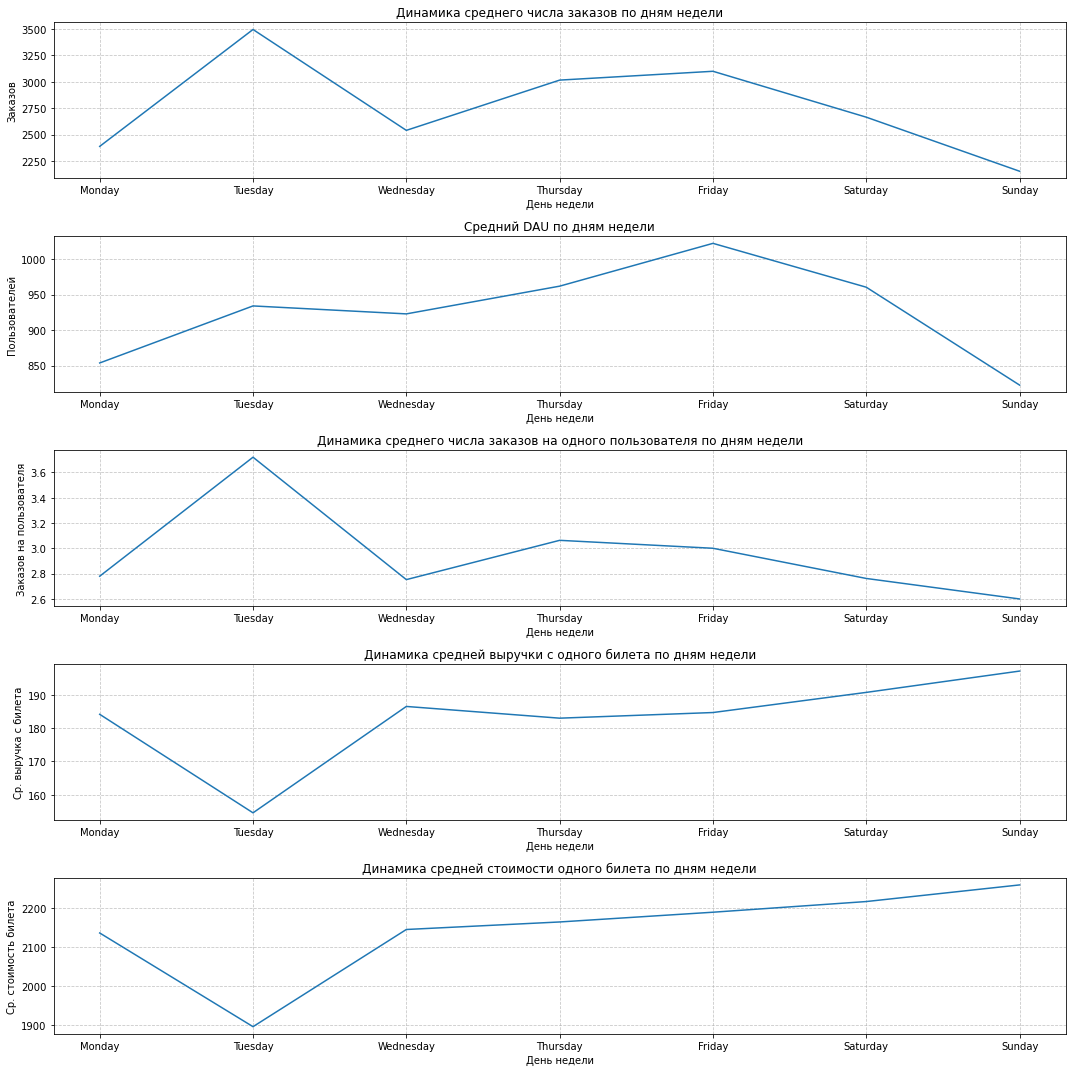

In [48]:
# Визуализируем все метрики отдельно
plt.figure(figsize = (15, 15))

plt.subplot(5, 1, 1)
avg_pivot_df[['day', 'avg_total_orders']].plot('day', ax = plt.gca(), legend = False)
plt.title('Динамика среднего числа заказов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Заказов')
plt.grid(True, linestyle = '--', alpha=0.7) # cетка

plt.subplot(5, 1, 2)
avg_pivot_df[['day', 'avg_DAU']].plot('day', ax = plt.gca(), legend = False)
plt.title('Средний DAU по дням недели')
plt.xlabel('День недели')
plt.ylabel('Пользователей')
plt.grid(True, linestyle = '--', alpha=0.7) # cетка

plt.subplot(5, 1, 3)
avg_pivot_df[['day', 'avg_orders_per_user']].plot('day', ax = plt.gca(), legend = False)
plt.title('Динамика среднего числа заказов на одного пользователя по дням недели')
plt.xlabel('День недели')
plt.ylabel('Заказов на пользователя')
plt.grid(True, linestyle = '--', alpha=0.7) # cетка

plt.subplot(5, 1, 4)
avg_pivot_df[['day', 'avg_revenue_pur_ticket']].plot('day', ax = plt.gca(), legend = False)
plt.title('Динамика средней выручки с одного билета по дням недели')
plt.xlabel('День недели')
plt.ylabel('Ср. выручка с билета')
plt.grid(True, linestyle = '--', alpha=0.7) # cетка

plt.subplot(5, 1, 5)
avg_pivot_df[['day', 'avg2_price']].plot('day', ax = plt.gca(), legend = False)
plt.title('Динамика средней стоимости одного билета по дням недели')
plt.xlabel('День недели')
plt.ylabel('Ср. стоимость билета')
plt.grid(True, linestyle = '--', alpha=0.7) # cетка

plt.tight_layout()
plt.show()

<a id='metka_3_2_3'></a>
#### Промежуточный вывод

- Ежедневная динамика общего числа заказов демонстрирует относительно стабильный спрос в обычные дни, но в определенные даты (3 сентября, 1 и 31 октября) происходят массовые покупки (вероятно, из-за акций, распродаж или запуска новинок).
- Ежедневная динамика пользователей плавно растет на протяжении всего периода, видимо аудитория стабильно расширяется.
- Ежедневная динамика среднего числа заказов на одного пользователя подобна динамике общего числа заказов. В обычные дни 2–3 заказа на человека, а в дни пиков (3 сентября, 1 и 31 октября) 5–6. И это не приход новых людей, а просто в дни акций пользователи делают значительно больше заказов за визит.
- Ежедневная динамика средней стоимости одного билета показывает, что в моменты пиков заказов наблюдается падение средней стоимости билета. Вероятно, в дни пиков использовались скидки, а в обычные дни средний чек возвращался к норме.
- Наивысшая активность по количеству заказов приходится на вторник и пятницу, по числу пользователей (DAU) на пятницу.
- Показатель «заказов на пользователя» наиболее высок во вторник, что может свидетельствовать о повышенной лояльности или срочности покупок в этот день.
- У выходных дней стабильно низкие показатели по всем ключевым метрикам (кроме стоимости билета), что говорит о снижении деловой и покупательской активности в конце недели.
- Средняя же стоимость билета демонстрирует обратную динамику: она минимальна во вторник (вероятно, из-за большого объёма продаж и акций) и постепенно растёт к воскресенью, достигая своего максимума в этот день.

Таким образом, можно:
- оптимизировать маркетинговые акции под «горячие» дни (вторник, пятница),
- во вторник предлагать комплексные покупки (например, пакет билетов на несколько мероприятий) или скидки на объём, так как пользователи склонны в этот день брать больше,
- планировать распродажи на пики спроса,
- Учитывая обратную зависимость между активностью и средней стоимостью билета, во вторник, когда минимальная цена, стоит использовать этот день для «бюджетных» категорий или массовых мероприятий, а воскресенье - подходящее время для продвижения премиальных событий или билетов в лучшие сектора.

<a id='metka_3_3'></a>
### Популярные сегменты

<a id='metka_3_3_1'></a>
#### Топ-регионы

In [49]:
# Создаем сводную таблицу, сгруппированную по регионам, с нужными метриками
region_df = total_df.groupby('region_name').agg(
    total_orders_abs = ('order_id', 'count'),           # общее число заказов
    unique_events_abs = ('event_id', 'nunique'),        # количество уникальных мероприятий
    total_revenue_abs = ('revenue_rub', 'sum'),         # общая выручка региона
    unique_users_abs = ('user_id', 'nunique'),          # количество уникальных клиентов
    avg_revenue = ('revenue_rub', 'mean'),              # средний чек - для выявления платежеспособности регионов
    total_tickets_abs = ('tickets_count', 'sum')        # количество проданных билетов
).reset_index()

# Добавляем метрики для анализа
region_df['ticket_cost_abs'] = region_df['total_revenue_abs'] / region_df['total_tickets_abs']     # средняя выручка с билета
region_df['total_orders_otn'] = region_df['total_orders_abs'] / total_df['order_id'].count()       # доля заказов
region_df['unique_events_otn'] = region_df['unique_events_abs'] / total_df['event_id'].nunique()   # доля уникальных мероприятий
region_df['total_revenue_otn'] = region_df['total_revenue_abs'] / total_df['revenue_rub'].sum()    # доля выручки
region_df['unique_users_otn'] = region_df['unique_users_abs'] / region_df['unique_users_abs'].sum()# доля уникальных клиентов
region_df['orders_per_event'] = region_df['total_orders_abs'].div(region_df['unique_events_abs'], fill_value=0)# зак-в на мероп.

# Выводим топ-5 регионов с наибольшим разнообразием мероприятий
region_df.sort_values(by='unique_events_abs', ascending=False).head()

,region_name,total_orders_abs,unique_events_abs,total_revenue_abs,unique_users_abs,avg_revenue,total_tickets_abs,ticket_cost_abs,total_orders_otn,unique_events_otn,total_revenue_otn,unique_users_otn,orders_per_event
24,Каменевский регион,89637,5933,5.588612e+07,10550,623.471545,245824,227.341996,0.311518,0.265233,0.375206,0.185916,15.108208
61,Североярская область,43620,3797,2.197632e+07,6683,503.812853,122292,179.703633,0.151594,0.169744,0.147544,0.117770,11.488017
78,Широковская область,16164,1232,8.627051e+06,3249,533.720037,45414,189.964563,0.056175,0.055076,0.057920,0.057255,13.120130
58,Светополянский округ,7500,1075,3.036751e+06,1659,404.900093,19955,152.179940,0.026065,0.048058,0.020388,0.029236,6.976744
53,Речиновская область,6265,702,2.629997e+06,1528,419.792083,16833,156.240563,0.021773,0.031383,0.017657,0.026927,8.924501


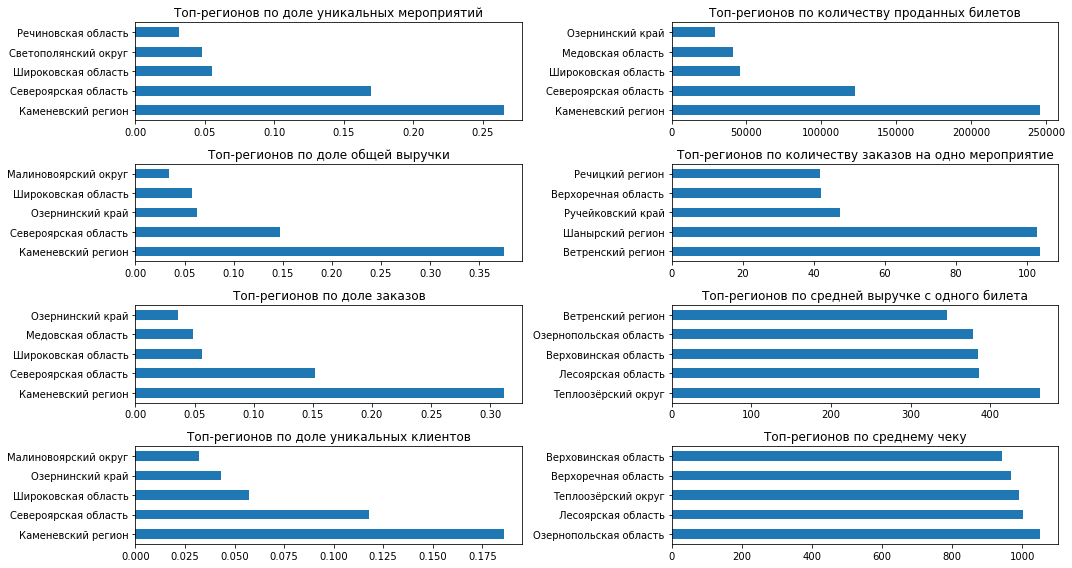

In [50]:
# Визуализируем основные метрики
fig, axes = plt.subplots(4, 2, figsize=(15, 8)) # графики будут распределены 4x2

# Топ-регионов по доле уникальных мероприятий
region_df.sort_values('unique_events_otn', ascending=False).head().plot(
    kind='barh', 
    x='region_name', 
    y='unique_events_otn', 
    title='Топ-регионов по доле уникальных мероприятий',
    ax=axes[0, 0],
    legend=False
)
axes[0, 0].set_ylabel('')  # убираем подпись оси Y

# Топ-регионов по доле общей выручки
region_df.sort_values('total_revenue_otn', ascending=False).head().plot(
    kind='barh', 
    x='region_name', 
    y='total_revenue_otn', 
    title='Топ-регионов по доле общей выручки',
    ax=axes[1, 0],
    legend=False
)
axes[1, 0].set_ylabel('')

# Топ-регионов по доле заказов
region_df.sort_values('total_orders_otn', ascending=False).head().plot(
    kind='barh', 
    x='region_name', 
    y='total_orders_otn', 
    title='Топ-регионов по доле заказов',
    ax=axes[2, 0],
    legend=False
)
axes[2, 0].set_ylabel('')

# Топ-регионов по доле уникальных клиентов
region_df.sort_values('unique_users_otn', ascending=False).head().plot(
    kind='barh',
    x='region_name',
    y='unique_users_otn', 
    title='Топ-регионов по доле уникальных клиентов',
    ax=axes[3, 0],
    legend=False
)
axes[3, 0].set_ylabel('')

# Топ-регионов по количеству проданных билетов
region_df.sort_values('total_tickets_abs', ascending=False).head().plot(
    kind='barh', 
    x='region_name', 
    y='total_tickets_abs', 
    title='Топ-регионов по количеству проданных билетов',
    ax=axes[0, 1],
    legend=False
)
axes[0, 1].set_ylabel('')

# Топ-регионов по количеству заказов на одно мероприятие
region_df.sort_values('orders_per_event', ascending=False).head().plot(
    kind='barh', 
    x='region_name', 
    y='orders_per_event', 
    title='Топ-регионов по количеству заказов на одно мероприятие',
    ax=axes[1, 1],
    legend=False
)
axes[1, 1].set_ylabel('')

# Топ-регионов по средней выручке с одного билета
region_df.sort_values('ticket_cost_abs', ascending=False).head().plot(
    kind='barh', 
    x='region_name', 
    y='ticket_cost_abs', 
    title='Топ-регионов по средней выручке с одного билета',
    ax=axes[2, 1],
    legend=False
)
axes[2, 1].set_ylabel('')

# Топ-регионов по среднему чеку
region_df.sort_values('avg_revenue', ascending=False).head().plot(
    kind='barh',
    x='region_name',
    y='avg_revenue', 
    title='Топ-регионов по среднему чеку',
    ax=axes[3, 1],
    legend=False
)
axes[3, 1].set_ylabel('')

plt.tight_layout()
plt.show() 

<a id='metka_3_3_2'></a>
#### Топ-партнёры

In [51]:
# Создаем сводную таблицу, сгруппированную по билетным партнёрам, с нужными метриками
service_df = total_df.groupby('service_name').agg(
    total_orders_abs = ('order_id', 'count'),           # общее число заказов
    unique_events_abs = ('event_id', 'nunique'),        # количество уникальных мероприятий
    total_revenue_abs = ('revenue_rub', 'sum'),         # общая выручка региона
    unique_users_abs = ('user_id', 'nunique'),          # количество уникальных клиентов
    avg_revenue = ('revenue_rub', 'mean'),              # средний чек - для выявления платежеспособности регионов
    total_tickets_abs = ('tickets_count', 'sum')        # количество проданных билетов
).reset_index()

# Добавляем метрики для анализа
service_df['ticket_cost_abs'] = service_df['total_revenue_abs'] / service_df['total_tickets_abs']  # средняя выручка с билета
service_df['total_orders_otn'] = service_df['total_orders_abs'] / total_df['order_id'].count()     # доля заказов
service_df['unique_events_otn'] = service_df['unique_events_abs'] / total_df['event_id'].nunique() # доля уникальных мероприятий
service_df['total_revenue_otn'] = service_df['total_revenue_abs'] / total_df['revenue_rub'].sum()  # доля выручки
service_df['unique_users_otn'] = service_df['unique_users_abs'] / service_df['unique_users_abs'].sum() # доля уникальн. клиентов
service_df['orders_per_event'] = service_df['total_orders_abs'].div(service_df['unique_events_abs'], fill_value=0)#зак-в на мер.

# Выводим топ-5 наиболее активных билетных партнеров (по количеству заказов)
service_df.sort_values(by='total_orders_abs', ascending=False).head()

,service_name,total_orders_abs,unique_events_abs,total_revenue_abs,unique_users_abs,avg_revenue,total_tickets_abs,ticket_cost_abs,total_orders_otn,unique_events_otn,total_revenue_otn,unique_users_otn,orders_per_event
3,Билеты без проблем,62887,4249,2.412841e+07,8814,383.678878,171377,140.791434,0.218553,0.189950,0.161992,0.161651,14.800424
21,Лови билет!,40796,4869,1.666815e+07,6346,408.573057,112680,147.924622,0.141779,0.217667,0.111906,0.116387,8.378723
5,Билеты в руки,40293,3536,1.319366e+07,5721,327.442889,112722,117.045974,0.140031,0.158076,0.088579,0.104924,11.395079
24,Мой билет,34417,1299,2.201642e+07,6229,639.696091,92729,237.427562,0.119610,0.058071,0.147813,0.114241,26.494996
25,Облачко,26402,2335,1.858861e+07,5341,704.060823,67778,274.257338,0.091755,0.104386,0.124799,0.097955,11.307066


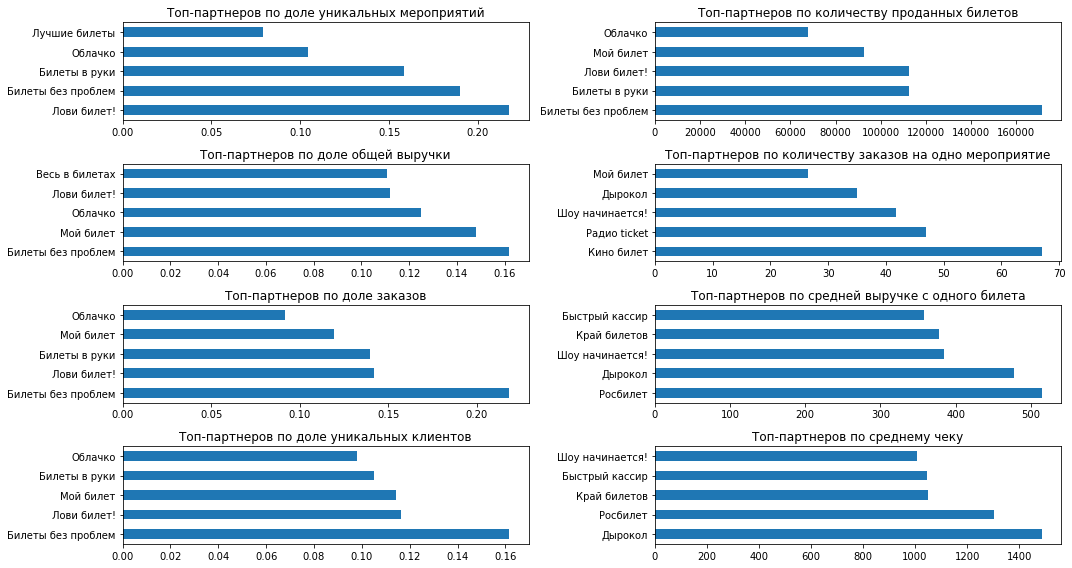

In [52]:
# Визуализируем основные метрики
fig, axes = plt.subplots(4, 2, figsize=(15, 8)) # графики будут распределены 4x2

# Топ-партнеров по доле уникальных мероприятий
service_df.sort_values('unique_events_otn', ascending=False).head().plot(
    kind='barh', 
    x='service_name', 
    y='unique_events_otn', 
    title='Топ-партнеров по доле уникальных мероприятий',
    ax=axes[0, 0],
    legend=False
)
axes[0, 0].set_ylabel('')

# Топ-партнеров по доле общей выручки
service_df.sort_values('total_revenue_otn', ascending=False).head().plot(
    kind='barh', 
    x='service_name', 
    y='total_revenue_otn', 
    title='Топ-партнеров по доле общей выручки',
    ax=axes[1, 0],
    legend=False
)
axes[1, 0].set_ylabel('')

# Топ-партнеров по доле заказов
service_df.sort_values('total_orders_otn', ascending=False).head().plot(
    kind='barh', 
    x='service_name', 
    y='total_orders_otn', 
    title='Топ-партнеров по доле заказов',
    ax=axes[2, 0],
    legend=False
)
axes[2, 0].set_ylabel('')

# Топ-партнеров по доле уникальных клиентов
service_df.sort_values('unique_users_otn', ascending=False).head().plot(
    kind='barh',
    x='service_name',
    y='unique_users_otn', 
    title='Топ-партнеров по доле уникальных клиентов',
    ax=axes[3, 0],
    legend=False
)
axes[3, 0].set_ylabel('')

# Топ-партнеров по количеству проданных билетов
service_df.sort_values('total_tickets_abs', ascending=False).head().plot(
    kind='barh', 
    x='service_name', 
    y='total_tickets_abs', 
    title='Топ-партнеров по количеству проданных билетов',
    ax=axes[0, 1],
    legend=False
)
axes[0, 1].set_ylabel('')

# Топ-партнеров по количеству заказов на одно мероприятие
service_df.sort_values('orders_per_event', ascending=False).head().plot(
    kind='barh', 
    x='service_name', 
    y='orders_per_event', 
    title='Топ-партнеров по количеству заказов на одно мероприятие',
    ax=axes[1, 1],
    legend=False
)
axes[1, 1].set_ylabel('')

# Топ-партнеров по средней выручке с одного билета
service_df.sort_values('ticket_cost_abs', ascending=False).head().plot(
    kind='barh', 
    x='service_name', 
    y='ticket_cost_abs', 
    title='Топ-партнеров по средней выручке с одного билета',
    ax=axes[2, 1],
    legend=False
)
axes[2, 1].set_ylabel('')

# Топ-партнеров по среднему чеку
service_df.sort_values('avg_revenue', ascending=False).head().plot(
    kind='barh',
    x='service_name',
    y='avg_revenue', 
    title='Топ-партнеров по среднему чеку',
    ax=axes[3, 1],
    legend=False
)
axes[3, 1].set_ylabel('')

plt.tight_layout()
plt.show() 

<a id='metka_3_3_3'></a>
#### Промежуточный вывод

- Каменевский регион — это явный лидер среди регионов (по доле общей выручки, доле заказов, по количеству проданных билетов, по доле уникальных мероприятий и уникальных клиентов). Верховинская и Верхоречная области, а также Теплоозёрский округ и Ветренский регион демонстрируют высокую маржинальность и платёжеспособность аудитории, хотя их вклад в общий объём выручки может быть меньше, чем у Каменевского региона. Шанырский и Ветренский регионы лидируют по метрике «количество заказов на одно мероприятие», они эффективно «продают» мероприятие, собирая большую аудиторию на единичных событиях. Но есть и регионы (Североярская и Широковская области, Озернинский край), которые не являются первыми, но занимают промежуточные позиции по всем показателям среди пятерок лидеров.
- Безусловным лидером среди билетных партнеров выступает "Билеты без проблем", доминирующий сразу по нескольким ключевым метрикам (по количеству проданных билетов, по доле уникальных клиентов, по доле заказов и доле общей выручки). Входит двойку лидеров по доле уникальных мероприятий, где лидер "Лови билет!". Последний, как и "Облачко", стабильно держится в топе по многим показателям. "Кино билет" — лидер по конверсии, а "Дырокол" самый платежеспособный.
- Таким образом, структура рынка неравномерная, но сбалансированная, где один явный лидер (Каменевский регион и партнер "Билеты без проблем"), обеспечивающий основной объём продаж, выручки и клиентской базы, а так же несколько сильных конкурентов, которые закрывают разные потребности и обеспечивают стабильный, но не выдающийся вклад, удерживая аудиторию и ассортимент.

<a id='metka_4'></a>
## Статистический анализ данных

Становятся ли пользователи мобильных устройств более активными в плане частоты заказов по сравнению с пользователями стационарных устройств? Зачем это нужно бизнесу:
- Если мобильные пользователи делают больше заказов на человека, значит, мобильная воронка работает лучше. Тогда имеет смысл усиливать мобильную разработку и мобильный маркетинг.
- Если разницы нет или мобильные отстают — нужно искать узкие места именно в мобильном сценарии (скорость загрузки, сложность оформления и т.п.).

Проверим две гипотезы относительно активности пользователей мобильных и стационарных устройств. Гипотезы предполагают большую активность пользователей мобильных устройств. Используем данные только за осенний период.

Размер групп по количеству уникальных пользователей:
А: 14185, 89.76%
В: 4867,  30.80%

ВАЖНО: У групп есть общие пользователи. Условие независимости не выполняется!

    Количество общих пользователей: 3249
Доля общих пользователей в выборке: 20.56%


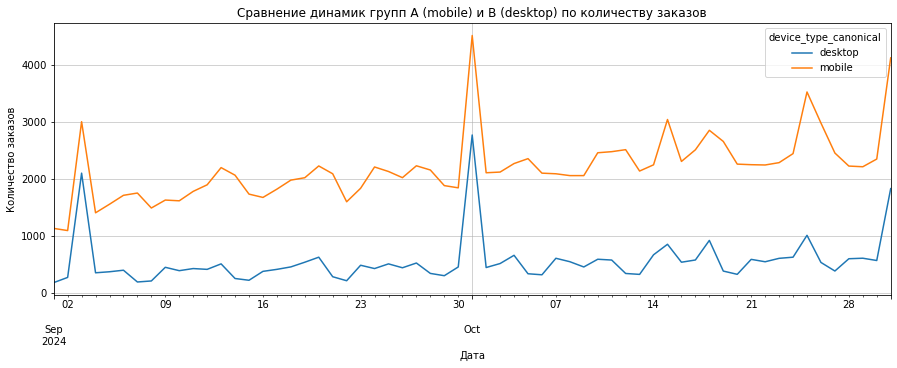

In [53]:
# Устанавливаем уровень значимости
alpha = 0.05

# Отфильтровываем только осень по условию эксперимента
df_exp = total_df[total_df['season'] == 'осень']

# Создаем выборки для контрольной (A) и экспериментальной (B) групп
A = df_exp[df_exp.device_type_canonical == 'mobile']  # пользователи мобильного приложения
B = df_exp[df_exp.device_type_canonical == 'desktop'] # пользователи стационарных устройств

# Определяем соотношение групп по количеству уникальных пользователей
print(f"""Размер групп по количеству уникальных пользователей:
А: {A['user_id'].nunique()}, {A['user_id'].nunique() / df_exp['user_id'].nunique():.2%}
В: {B['user_id'].nunique()},  {B['user_id'].nunique() / df_exp['user_id'].nunique():.2%}""")

# Проверяем пересечение групп: есть ли пользователи, которые присутствуют в обеих группах
intersection = set(A['user_id']) & set(B['user_id'])

# Если есть пересечения — выводим предупреждение и показываем, как они влияют на метрику
if len(intersection) > 0:
    print("\nВАЖНО: У групп есть общие пользователи. Условие независимости не выполняется!")
    A_clean = A[~A['user_id'].isin(intersection)].copy()
    B_clean = B[~B['user_id'].isin(intersection)].copy()
else:
    print("\nОбщих пользователей у групп не обнаружено. Условие независимости выполняется!")

print(f"""\n    Количество общих пользователей: {len(intersection)}
Доля общих пользователей в выборке: {len(intersection) / df_exp['user_id'].nunique():.2%}""")

# Проверяем сопоставимость групп по размеру в течении всего эксперимента, т.е. нет ли сильного дисбаланса (визуализация)
plt.figure(figsize=(15, 5))
df_exp.groupby(['created_dt_msk', 'device_type_canonical'])['order_id'].count().unstack().plot(ax = plt.gca())
plt.title('Сравнение динамик групп А (mobile) и В (desktop) по количеству заказов')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.grid(True, alpha=0.7)
plt.show()

<a id='metka_4_1'></a>
### Гипотеза 1

- Нулевая гипотеза (H0): среднее количество заказов на одного пользователя у мобильных пользователей не выше, чем у пользователей стационарных устройств (H0: muA = muB).
- Альтернативная гипотеза (H1): среднее количество заказов на одного пользователя у мобильных пользователей выше, чем у пользователей стационарных устройств (H1: muA > muB).

Целевая метрика - среднее количество заказов на пользователя. Поскольку это метрика «на пользователя», которая не будет долей или отношением, можно утверждать, что она непрерывна. Это позволяет использовать для её анализа t-тест.

Среднее кол-во заказов общих польз-лей: 41.26
Среднее кол-во заказов по всей выборке: 10.66
Общие пользователи в среднем делают БОЛЬШЕ заказов (в 3.9 раза).

Размер групп по количеству заказов:
А: 134246, 79.67%
В: 34256,  20.33%


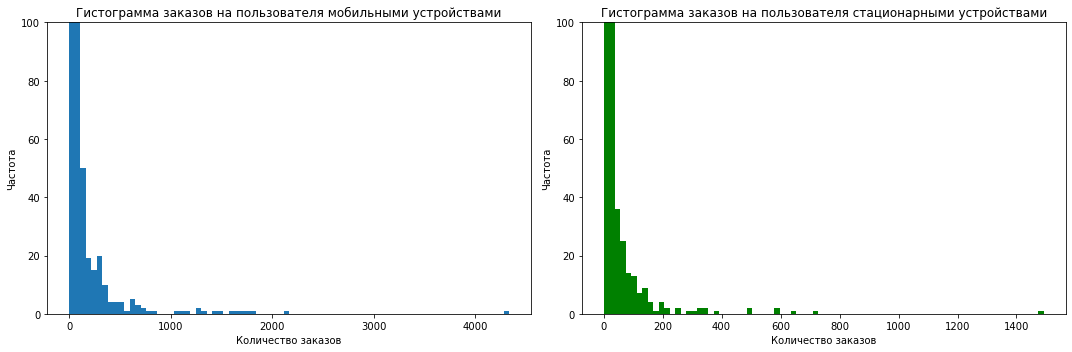


Тест Левене: p-value=0.019811070791893516 ≤ 0.05 — дисперсии в группах различаются.

     T-тест: p-value=0.0008022925790669811 ≤ 0.05 - отвергаем H0: среднее количество заказов у мобильных пользователей выше.

Манна-Уитни: p-value=3.338856382551332e-07 ≤ 0.05 - отвергаем H0.


In [54]:
# I вариант: проводим A/B-тест при нарушении условия независимости групп, но с серьёзными ограничениями и рисками.

# Если есть пересечение, смотрим насколько общие для обеих групп пользователи «активнее/пассивнее»
df1 = df_exp[df_exp['user_id'].isin(intersection)]['order_id'].count() / len(intersection)
df2 = df_exp['order_id'].count() / df_exp['user_id'].nunique()

print(f"""Среднее кол-во заказов общих польз-лей: {df1:.2f}
Среднее кол-во заказов по всей выборке: {df2:.2f}""")

if df1 > df2:
    print(f"Общие пользователи в среднем делают БОЛЬШЕ заказов (в {df1/df2:.1f} раза).")
elif df1 < df2:
    print(f"Общие пользователи в среднем делают МЕНЬШЕ заказов (в {df2/df1:.1f} раза).")

# Определяем соотношение зависимых групп по количеству заказов
print(f"""\nРазмер групп по количеству заказов:
А: {A['order_id'].nunique()}, {A['order_id'].nunique() / df_exp['order_id'].nunique():.2%}
В: {B['order_id'].nunique()},  {B['order_id'].nunique() / df_exp['order_id'].nunique():.2%}""")

# Считаем количество заказов на каждого пользователя для каждой группы
muA1 = A.groupby('user_id')['order_id'].count()
muB1 = B.groupby('user_id')['order_id'].count()

# Проверяем выполнение условия нормальности (визуализация)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(muA1, bins=80)
axes[0].set_title('Гистограмма заказов на пользователя мобильными устройствами')
axes[0].set_xlabel('Количество заказов')
axes[0].set_ylabel('Частота')
axes[0].set_ylim(0, 100)  # ограничение оси Y

axes[1].hist(muB1, bins=80, color='green')
axes[1].set_title('Гистограмма заказов на пользователя стационарными устройствами')
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Частота')
axes[1].set_ylim(0, 100)  # ограничение оси Y

plt.tight_layout()
plt.show()

# Проверяем равенство дисперсий тестом Левене: если дисперсии равны, при t-тесте equal_var=True, в противном случае - False.
l_stat, l_p = stats.levene(muA1, muB1)
if l_p > alpha:
    print(f"\nТест Левене: p-value={l_p} > {alpha} — дисперсии в группах можно считать равными.")
else:
    print(f"\nТест Левене: p-value={l_p} ≤ {alpha} — дисперсии в группах различаются.")

# Проверяем гипотезу t-тестом (muA > muB)
equal_var = l_p > alpha # если дисперсии равны, equal_var=True, иначе False
t_stat, t_p = stats.ttest_ind(muA1, muB1, equal_var = equal_var, alternative = 'greater')
if t_p < alpha:
    print(f"\n     T-тест: p-value={t_p} ≤ {alpha} - отвергаем H0: среднее количество заказов у мобильных пользователей выше.")
else:
    print(f"\n     T-тест: p-value={t_p} > {alpha} - нет оснований отвергать H0: недостаточно доказательств, что среднее количество заказов у мобильных пользователей выше.")

# Проверяем гипотезу тестом Манна-Уитни (muA > muB)
mw_stat, mw_p = stats.mannwhitneyu(muA1, muB1, alternative = 'greater')
if mw_p < alpha:
    print(f"\nМанна-Уитни: p-value={mw_p} ≤ {alpha} - отвергаем H0.")
else:
    print(f"\nМанна-Уитни: p-value={mw_p} > {alpha} - нет оснований отвергать H0.")


Размер НЕЗАВИСИМЫХ групп по количеству заказов:
А: 31263, 18.55%
В: 3195,  1.90%


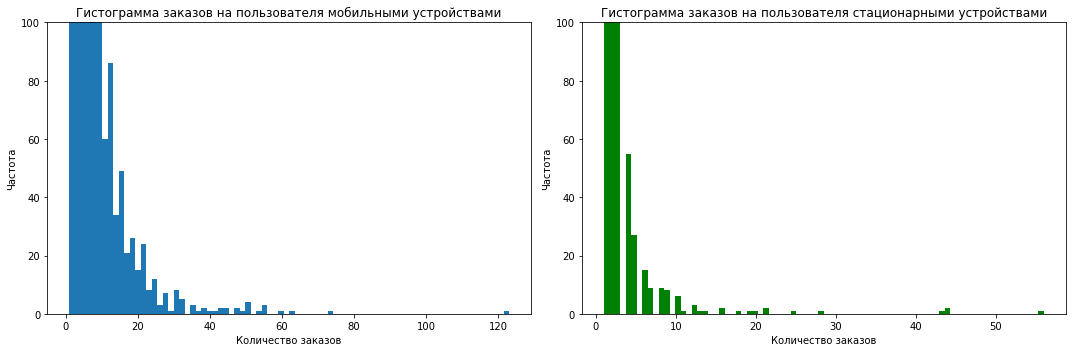


Тест Левене: p-value=1.0141571398521047e-18 ≤ 0.05 — дисперсии в группах различаются.

     T-тест: p-value=8.080573285342692e-25 ≤ 0.05 - отвергаем H0: среднее количество заказов у мобильных пользователей выше.

Манна-Уитни: p-value=6.313555559977915e-39 ≤ 0.05 - отвергаем H0.


In [55]:
# II вариант: проводим A/B-тест, выполняя условие независимости групп.

# Определяем соотношение независимых групп по количеству заказов
print(f"""\nРазмер НЕЗАВИСИМЫХ групп по количеству заказов:
А: {A_clean['order_id'].nunique()}, {A_clean['order_id'].nunique() / df_exp['order_id'].nunique():.2%}
В: {B_clean['order_id'].nunique()},  {B_clean['order_id'].nunique() / df_exp['order_id'].nunique():.2%}""")

# Считаем количество заказов на каждого пользователя для каждой группы
muA_clean1 = A_clean.groupby('user_id')['order_id'].count()
muB_clean1 = B_clean.groupby('user_id')['order_id'].count()

# Проверяем выполнение условия нормальности (визуализация)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(muA_clean1, bins=80)
axes[0].set_title('Гистограмма заказов на пользователя мобильными устройствами')
axes[0].set_xlabel('Количество заказов')
axes[0].set_ylabel('Частота')
axes[0].set_ylim(0, 100)  # ограничение оси Y

axes[1].hist(muB_clean1, bins=80, color='green')
axes[1].set_title('Гистограмма заказов на пользователя стационарными устройствами')
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Частота')
axes[1].set_ylim(0, 100)  # ограничение оси Y

plt.tight_layout()
plt.show()

# Проверяем равенство дисперсий тестом Левене: если дисперсии равны, при t-тесте equal_var=True, в противном случае - False.
l_stat_clean, l_p_clean = stats.levene(muA_clean1, muB_clean1)
if l_p_clean > alpha:
    print(f"\nТест Левене: p-value={l_p_clean} > {alpha} — дисперсии в группах можно считать равными.")
else:
    print(f"\nТест Левене: p-value={l_p_clean} ≤ {alpha} — дисперсии в группах различаются.")

# Проверяем гипотезу t-тестом (muA > muB)
equal_var_clean = l_p_clean > alpha # если дисперсии равны, equal_var=True, иначе False
t_stat_clean, t_p_clean = stats.ttest_ind(muA_clean1, muB_clean1, equal_var = equal_var_clean, alternative = 'greater')
if t_p_clean < alpha:
    print(f"\n     T-тест: p-value={t_p_clean} ≤ {alpha} - отвергаем H0: среднее количество заказов у мобильных пользователей выше.")
else:
    print(f"\n     T-тест: p-value={t_p_clean} > {alpha} - нет оснований отвергать H0: недостаточно доказательств, что среднее количество заказов у мобильных пользователей выше.")

# Проверяем гипотезу тестом Манна-Уитни (muA > muB)
mw_stat_clean, mw_p_clean = stats.mannwhitneyu(muA_clean1, muB_clean1, alternative = 'greater')
if mw_p_clean < alpha:
    print(f"\nМанна-Уитни: p-value={mw_p_clean} ≤ {alpha} - отвергаем H0.")
else:
    print(f"\nМанна-Уитни: p-value={mw_p_clean} > {alpha} - нет оснований отвергать H0.")

<a id='metka_4_2'></a>
### Гипотеза 2

- Нулевая гипотеза (H0): среднее время между заказами пользователей мобильных приложений не выше, чем у пользователей стационарных устройств (H0: muA = muB).
- Альтернативная гипотеза (H1): среднее время между заказами пользователей мобильных приложений выше, чем у пользователей стационарных устройств (H1: muA > muB).

Среднее время между заказами у общих пользователей: 9.5 дн.
Среднее время между заказами по всей выборке:       20.9 дн.
Общие пользователи в среднем делают заказы ЧАЩЕ (меньше дней между заказами).

Размер выборок
до удаления пользователей без интервалов:
A: 14185
B: 4867

после удаления пользователей без интервалов:
A: 10116
B: 4022

Доля потерь:
A: 0.3
B: 0.2


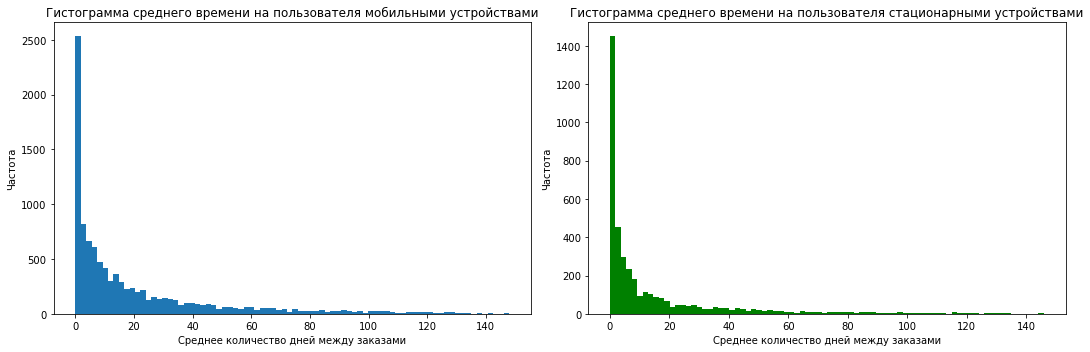


Тест Левене: p-value=5.7591585951449556e-21 ≤ 0.05 — дисперсии различаются.

T‑тест: p-value=4.7590739167873344e-34 ≤ 0.05 — отвергаем H0: среднее время между заказами у мобильных выше.

Манна‑Уитни: p-value=5.3081968064139974e-52 ≤ 0.05 — отвергаем H0.


In [56]:
# I вариант: проводим A/B-тест при нарушении условия независимости групп, но с серьёзными ограничениями и рисками.
# Если есть пересечение, смотрим насколько общие для обеих групп пользователи «активнее/пассивнее»
df3 = df_exp[df_exp['user_id'].isin(intersection)].dropna(subset=['days_since_prev']) # общие пользователи с интервалами
avg_df3 = df3.groupby('user_id')['days_since_prev'].mean().mean() # среднее от среднего времени между заказами для общих польз.
    
df4 = df_exp.dropna(subset=['days_since_prev'])                   # все пользователи с интервалами
avg_df4 = df4.groupby('user_id')['days_since_prev'].mean().mean() # среднее от среднего времени между заказами для всех польз.
    
print(f"""Среднее время между заказами у общих пользователей: {avg_df3:.1f} дн.
Среднее время между заказами по всей выборке:       {avg_df4:.1f} дн.""")

if avg_df3 > avg_df4:
    print("Общие пользователи в среднем делают заказы РЕЖЕ (больше дней между заказами).")
elif avg_df3 < avg_df4:
    print("Общие пользователи в среднем делают заказы ЧАЩЕ (меньше дней между заказами).")

# Группируем по пользователю и считаем среднее по интервалам 
muA2 = A.dropna(subset=['days_since_prev']).groupby('user_id')['days_since_prev'].mean()
muB2 = B.dropna(subset=['days_since_prev']).groupby('user_id')['days_since_prev'].mean()

# Определяем соотношение групп по количеству уникальных пользователей до/после удаления пользователей без интервалов
print(f"""\nРазмер выборок
до удаления пользователей без интервалов:
A: {A['user_id'].nunique()}
B: {B['user_id'].nunique()}

после удаления пользователей без интервалов:
A: {len(muA2)}
B: {len(muB2)}

Доля потерь:
A: {((A['user_id'].nunique() - len(muA2)) / A['user_id'].nunique()):.1f}
B: {((B['user_id'].nunique() - len(muB2)) / B['user_id'].nunique()):.1f}""")

# Проверяем выполнение условия нормальности (визуализация)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(muA2, bins = 80)
axes[0].set_title('Гистограмма среднего времени на пользователя мобильными устройствами')
axes[0].set_xlabel('Среднее количество дней между заказами')
axes[0].set_ylabel('Частота')

axes[1].hist(muB2, bins = 80, color = 'green')
axes[1].set_title('Гистограмма среднего времени на пользователя стационарными устройствами')
axes[1].set_xlabel('Среднее количество дней между заказами')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Проверяем равенство дисперсий тестом Левене: если дисперсии равны, при t-тесте equal_var=True, в противном случае - False.
l_stat2, l_p2 = stats.levene(muA2, muB2)
if l_p2 > alpha:
    print(f"\nТест Левене: p-value={l_p2} > {alpha} — дисперсии можно считать равными.")
else:
    print(f"\nТест Левене: p-value={l_p2} ≤ {alpha} — дисперсии различаются.")

# Проверяем гипотезу t-тестом (muA > muB)
equal_var2 = l_p2 > alpha
t_stat2, t_p2 = stats.ttest_ind(muA2, muB2, equal_var = equal_var2, alternative = 'greater')
if t_p2 < alpha:
    print(f"\nT‑тест: p-value={t_p2} ≤ {alpha} — отвергаем H0: среднее время между заказами у мобильных выше.")
else:
    print(f"\nT‑тест: p-value={t_p2} > {alpha} — нет оснований отвергать H0.")

# Проверяем гипотезу тестом Манна-Уитни (muA > muB)
mw_stat2, mw_p2 = stats.mannwhitneyu(muA2, muB2, alternative = 'greater')
if mw_p2 < alpha:
    print(f"\nМанна‑Уитни: p-value={mw_p2} ≤ {alpha} — отвергаем H0.")
else:
    print(f"\nМанна‑Уитни: p-value={mw_p2} > {alpha} — нет оснований отвергать H0.")


Размер НЕЗАВИСИМЫХ выборок:
до удаления пользователей без интервалов:
A: 10936
B: 1618
после удаления пользователей без интервалов:
A: 6989
B: 885
Доля потерь:
A: 0.4
B: 0.5


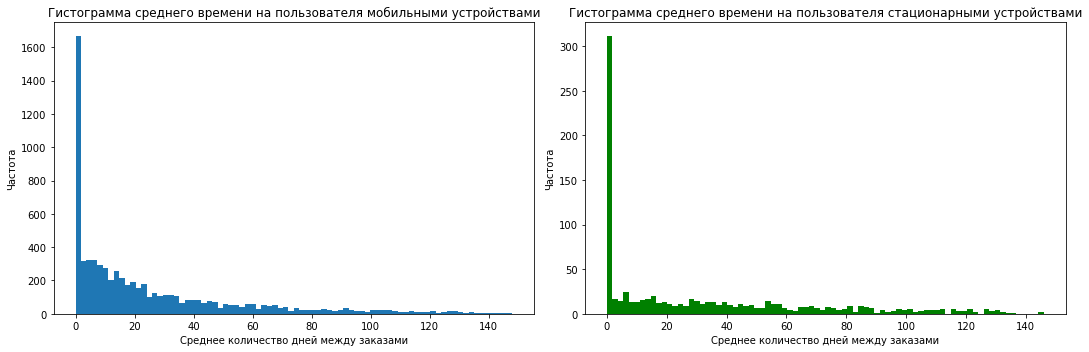


Тест Левене: p-value=4.033842057727268e-17 ≤ 0.05 — дисперсии различаются.

T‑тест: p-value=0.9999995125034684 > 0.05 — нет оснований отвергать H0.

Манна‑Уитни: p-value=0.8575243593392585 > 0.05 — нет оснований отвергать H0.


In [57]:
# II вариант: проводим A/B-тест, выполняя условие независимости групп.
# Если есть пересечение, смотрим насколько общие для обеих групп пользователи «активнее/пассивнее»

# Группируем по пользователю и считаем среднее по интервалам 
muA_clean2 = A_clean.dropna(subset=['days_since_prev']).groupby('user_id')['days_since_prev'].mean()
muB_clean2 = B_clean.dropna(subset=['days_since_prev']).groupby('user_id')['days_since_prev'].mean()

# Определяем соотношение независимых групп по количеству уникальных пользователей до/после удаления пользователей без интервалов
print(f"""\nРазмер НЕЗАВИСИМЫХ выборок:
до удаления пользователей без интервалов:
A: {A_clean['user_id'].nunique()}
B: {B_clean['user_id'].nunique()}
после удаления пользователей без интервалов:
A: {len(muA_clean2)}
B: {len(muB_clean2)}
Доля потерь:
A: {((A_clean['user_id'].nunique() - len(muA_clean2)) / A_clean['user_id'].nunique()):.1f}
B: {((B_clean['user_id'].nunique() - len(muB_clean2)) / B_clean['user_id'].nunique()):.1f}""")

# Проверяем выполнение условия нормальности (визуализация)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(muA_clean2, bins = 80)
axes[0].set_title('Гистограмма среднего времени на пользователя мобильными устройствами')
axes[0].set_xlabel('Среднее количество дней между заказами')
axes[0].set_ylabel('Частота')

axes[1].hist(muB_clean2, bins = 80, color = 'green')
axes[1].set_title('Гистограмма среднего времени на пользователя стационарными устройствами')
axes[1].set_xlabel('Среднее количество дней между заказами')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Проверяем равенство дисперсий тестом Левене: если дисперсии равны, при t-тесте equal_var=True, в противном случае - False.
l_stat2_clean, l_p2_clean = stats.levene(muA_clean2, muB_clean2)
if l_p2_clean > alpha:
    print(f"\nТест Левене: p-value={l_p2_clean} > {alpha} — дисперсии можно считать равными.")
else:
    print(f"\nТест Левене: p-value={l_p2_clean} ≤ {alpha} — дисперсии различаются.")

# Проверяем гипотезу t-тестом (muA > muB)
equal_var2_clean = l_p2_clean > alpha
t_stat2_clean, t_p2_clean = stats.ttest_ind(muA_clean2, muB_clean2, equal_var = equal_var2_clean, alternative = 'greater')
if t_p2_clean < alpha:
    print(f"\nT‑тест: p-value={t_p2_clean} ≤ {alpha} — отвергаем H0: среднее время между заказами у мобильных выше.")
else:
    print(f"\nT‑тест: p-value={t_p2_clean} > {alpha} — нет оснований отвергать H0.")

# Проверяем гипотезу тестом Манна-Уитни (muA > muB)
mw_stat2_clean, mw_p2_clean = stats.mannwhitneyu(muA_clean2, muB_clean2, alternative = 'greater')
if mw_p2_clean < alpha:
    print(f"\nМанна‑Уитни: p-value={mw_p2_clean} ≤ {alpha} — отвергаем H0.")
else:
    print(f"\nМанна‑Уитни: p-value={mw_p2_clean} > {alpha} — нет оснований отвергать H0.")

<a id='metka_4_3'></a>
### Промежуточный вывод

- Пропуски и дубликаты в выборках отсутствуют.
- Размер выборок достаточен для применения t‑теста и Манна‑Уитни (при условии корректности дизайна).
- ВАЖНО: не выполняется условие независимости, потому что имеется 3249 общих для обеих групп пользователей, что составляет существенную долю выборки (20,56%) для их исключения из эксперимента.
- Динамика количества заказов (визуализация) в тестовой и контрольной группах остаётся стабильной на протяжении всего эксперимента. Обе группы достигают пиков в одни и те же даты и затем синхронно снижаются. Ни в одной из групп нет резких провалов или скачков, которых не было бы в другой группе. Кроме того динамика на графике подтверждает преимущество мобильной группы A, но нужно дождаться статистического подтверждения.
- Выполнять A/B-тест при нарушении условия независимости групп можно, но с серьёзными ограничениями и рисками.

Гипотеза 1:
- Исключение 20% данных, да ещё и пользователей, которые активнее (в среднем делают больше заказов в 4 раза), чем вся выборка исказило бы картину. Но и нарушение условия независимости групп ведет к возникновению риска искажения данных и неверных выводов. Поэтому было принято решение рассматривать 2 варианта событий для А/В-теста:с пересечением и без, т.е. с независимыми выборками.
- Условие нормальности (визуализация) тоже не выполнено и, учитывая ЦПТ (при достаточно больших размерах выборок распределение выборочных средних стремится к нормальному, даже если исходные данные распределены ненормально) был применен t-тест Уэлча (дисперсии в группах оказались различны), работающий с распределением средних, а не с исходными данными.
- Поскольку распределение ненормальное кроме t-теста дополнительно был применен критерий Манна-Уитни (непараметрический тест), который сравнивает ранги значений и устойчив к выбросам.
- В результате в I варианте результаты показывают статистическую значимость, НО нарушена независимость выборок, что снижает надежность выводов. Но и во II варианте, с независимыми выборками, получены аналогичные результаты с очень малыми p-value. И можно было бы с высокой уверенностью склоняться к тому, что мобильные пользователи делают действительно больше заказов, чем стационарные, НО СУЩЕСТВУЕТ ОГОВОРКА на не соблюдение условия независимости в I варианте и сильный дисбаланс размера групп (группа A превосходит группу В почти в 10 раз), исключение наиболее активных пользователей и уменьшение самой выборки во II варианте с независимыми выборками!
- Рекомендуется по возможности исправить дизайн эксперимента и пересмотреть способ распределения пользователей по группам. Текущий дизайн порождает зависимость данных. Даже статистически значимые результаты в таких условиях требуют дополнительной проверки и осторожности при внедрении изменений.

Гипотеза 2:
- Аналогично первой гипотезе, было также рассмотрено два сценария: с пересечением (общие пользователи активнее и в среднем делают заказы чаще) и с независимыми выборками.
- Результаты А/В тестов пересекающихся выборок и независимых дали (в отличие от гипотезы 1) разные результаты. Поэтому результат теста пересекающихся выборок нельзя считать достоверными, так как нарушено условие независимости выборок. Но этот блок оставлен исключительно для иллюстрации искажений.
- Результаты А/В тестов независимых выборок - статистически значимого доказательства того, что мобильные пользователи делают заказы реже (имеют большее время между заказами), не обнаружено. Но это не означает отсутствие эффекта, а лишь то, что выборка недостаточна для его подтверждения, ведь после очистки от пересечений размер группы B (893 пользователя) оказался критически мал по сравнению с A (7052), что снизило мощность теста.
- Эффект не подтверждён из-за ограничений выборки, а не из-за отсутствия разницы и в дальнейшем рекомендуется, например, увеличить размер выборки в группе B для будущих тестов.

<a id='metka_5'></a>
## Итоговый вывод и рекомендации

<a id='metka_5_1'></a>
### Общий вывод

Информация о данных:
- Работа проводилась на основании трех датафреймов (с информацией о заказах билетов, о мероприятиях на сервисе онлайн-продажи билетов и о курсе тенге к рублю в 2024 году), больший из которых содержал почти 300 тыс.строк.
- Значения в столбцах соответствовали своему описанию и необходимости приведения к единому виду не было.
- Пропуски содержались только в одном столбце `days_since_prev` (количество дней после последней покупки) и были объяснимы (заказ у пользователя был первым).
- Не все столбцы имели типы данных, соответствующие содержимому. Часть строковых столбцов позже была приведена к типам `datetime` или `category`, а часть была оптимизирована понижением размерности.
- Три датафрейма были объединины в единый, с которым в дальнейшем проводился анализ.
- Было заменено 238 пропусков в категориальных столбцах на значение unknown, которые образовались после слияния датафреймов, пропуски в количественных столбцах не должны были повлиять на дальнейший анализ и были оставлены без изменений.
- В результате фильтрации по 99 процентилю по выручке и количеству билетов было отсечено чуть больше 1% данных с российской валютой и менее 1% данных с казахстанским тенге.
- Удалено неявных дублей (0,01%).
- В общей сложности было потеряно 1,07% исходных данных, что незначительно для дальнейшего анализа.
- В общий датафрейм с 24 столбцами позже было добавлено еще 5 новых столбцов, которые использовались в дальнейшем анализе.

Основные результаты исследовательского анализа:
- Количество заказов стабильно растет с июня по октябрь и действительно наблюдается резкий рост общей доли заказов в осеннем сезоне по сравнению с летним.
- Как летом, так и осенью пользователи предпочитают совершать покупки с мобильных устройств.
- Осенью аудитория становится более разнообразной, смещаясь в сторону и детского, и молодежного контента.
- Концерты являются безоговорочным лидером по доле заказов в любой сезон, но их относительное влияние ослабевает с приходом осени.
- Спортивные мероприятия - драйвер осенних продаж наряду с ёлками и театром (осень - предновогодний период, сезон старта спортивных лиг и турниров, начало театрального сезона).
- Подтверждается общее осеннее удешевление билетов по основным массовым категориям, возможно, из-за периода роста спроса, ведь обычно ближе к дате мероприятия (Новогодние спектакли и постановки) часто запускают акции и снижают цены.
- Графики ежедневной динамики продемонстрировали относительно стабильный спрос и число заказов на одного пользователя в обычные дни и плавный рост числа пользователей. Но в определенные даты происходили массовые покупки и в эти же дни падала средняя стоимость одного билета. В обычные дни средний чек возвращался к норме. Видимо, в дни акций пользователи делают значительно больше заказов за визит.
- Отчетливо прослеживается недельная цикличность с пиком в середине недели и снижением к выходным: активность пользователей, их приток и количество покупок за сессию максимальны в середине недели, к концу недели спрос падает, а аудитория сужается. Но средний чек и стоимость билета в середине недели снижаются, а в выходные объем падает, но средний чек растет — пользователи покупают более дорогие билеты.
- Структура рынка неравномерная, но сбалансированная, где один явный лидер (Каменевский регион и партнер "Билеты без проблем"), обеспечивающий основной объём продаж, выручки и клиентской базы, а также несколько сильных конкурентов, которые закрывают разные потребности и обеспечивают стабильный, но не выдающийся вклад, удерживая аудиторию и ассортимент.

Основные результаты статистического анализа:
- Дизайн эксперимента предполагает распределение по группам пользователей мобильных и стационарных устройств.
- Динамика количества заказов (визуализация) в тестовой и контрольной группах остаётся стабильной на протяжении всего эксперимента и подтверждает преимущество мобильной группы A, но нужно дождаться статистического подтверждения.
- Подобный дизайн приводит к невыполнению условия независимости, потому что имеется 3249 общих для обеих групп пользователей (20,56%).
- Для обеих гипотез я решила рассматривать по 2 сценария А/В-теста, каждый из которых неидеален: рассматривать выборки с пересечением (нарушение условия независимости групп ведет к возникновению риска искажения данных и неверных выводов) и без (уменьшение выборки на достаточно большой объем данных, причем данных по пользователям с наибольшей активностью). Кроме того наблюдается сильный дисбаланс размера групп, что снижает мощность тестов.
- Условие нормальности (визуализации) тоже не выполнялось, но учитывая ЦПТ был применен t-тест Уэлча (дисперсии в группах оказались различны), работающий с распределением средних, а не с исходными данными, и дополнительно был применен критерий Манна-Уитни, который сравнивает ранги значений и устойчив к выбросам.
- В результате А/В-тестов Гипотезы 1 оба варианта сценария показали статистическую значимость и можно было бы с высокой уверенностью склоняться к тому, что мобильные пользователи действительно делают больше заказов, чем стационарные, НО СУЩЕСТВУЕТ ОГОВОРКА на не соблюдение условия независимости в I варианте и сильный дисбаланс размера групп, исключение наиболее активных пользователей и уменьшение самой выборки во II варианте с независимыми выборками!
- В результате А/В-тестов Гипотезы 2 сценарии показали разные результаты. Результат теста пересекающихся выборок я не стала брать во внимание, так как все-таки нарушено условие независимости выборок. Результаты же А/В тестов независимых выборок не обнаружили статистически значимого доказательства того, что мобильные пользователи делают заказы реже (имеют большее время между заказами). Но выборка НЕДОСТАТОЧНА для подтверждения эффекта.

<a id='metka_5_2'></a>
### Рекомендации

- Активно использовать дни пиков спроса (начало и конец месяцев) — планировать на эти даты запуск акций, распродаж и новинок, так как именно в эти периоды пользователи готовы совершать больше покупок за визит.
- Осенью делать упор на снижение цен по массовым категориям (театры, ёлки, концерты) для стимулирования спроса, при этом сохраняя маржинальность в «дорогих» нишах (стендап).
- Усилить работу с Каменевским регионом и партнером «Билеты без проблем», но поддерживать лояльность аудитории в высокомаржинальных регионах (например, Верховинская область, Теплоозёрский округ).
- Планировать менее маржинальные предложения на середину недели, а более дорогие — на выходные, когда средний чек традиционно выше.
- По возможности исправить дизайн эксперимента и пересмотреть способ распределения пользователей по группам. Текущий дизайн порождает зависимость данных. Даже статистически значимые результаты в таких условиях требуют дополнительной проверки и осторожности при внедрении изменений. Рекомендуется, так же увеличить размер выборки в группе B для будущих тестов.